# Análise Exploratória: Inventário Processual
## NUCLEO-I e NUCLEO-II | 2024–2025

> **Fonte:** dados sintéticos gerados no notebook | **Ferramenta:** DuckDB + Python
> **Objetivo:** Caracterizar séries temporais mensais, verificar estacionariedade e previsibilidade, e fundamentar o monitoramento estatístico contínuo.

| Projeto | Filtro DuckDB | Contexto |
|---|---|---|
| **NUCLEO-I** | `CAO = 'NUCLEO-I'` | Processos Cíveis e Infracionais — mix judicial e extrajudicial |
| **NUCLEO-II** | `CAO = 'NUCLEO-II'` | Procedimentos Investigatórios — predominantemente extrajudicial |

## Variáveis do Dataset

### Selecionadas pelo pesquisador
| Coluna | Descrição |
|---|---|
| `DATA_FINALIZACAO` | Data de encerramento do processo |
| `DATA_INSTAURACAO` | Data de abertura |
| `CAO` | Coordenadoria de atuação |
| `MES_REFERENCIA` | Mês da fotografia do inventário |
| `ANO_REFERENCIA` | Ano da fotografia |
| `DIAS_DECORRIDOS` | Tempo de permanência no inventário (dias) |
| `NOME_ORGAO` | Órgão executor |

### Colunas adicionais identificadas na inspeção
| Coluna | Justificativa |
|---|---|
| `TIPO_CLASSE` | Discrimina **Judicial vs. Extrajudicial**. NUCLEO-I: ~50/50; NUCLEO-II: 93% extrajudicial — dinâmicas temporais distintas |
| `ATUACAO` | 27 categorias temáticas; estratificar por área reduz ruído nas séries *(Cleveland et al., 1990)* |
| `NOME_ASSUNTO_PRINCIPAL` | Assunto jurídico específico; útil para clustering temático |
| `NOME_COMARCA` | Dimensão geográfica; heterogeneidade espacial pode distorcer série agregada |

> **Achados da inspeção (2024–2025):**
> Dataset: **2.069.505** linhas, 53 colunas
> NUCLEO-I: **33.749** registros | Taxa de finalização: **47,8%**
> NUCLEO-II: **4.431** registros | Taxa de finalização: **17,3%**
> `DIAS_DECORRIDOS`: mediana=8 dias; média=128 dias (distribuição fortemente assimétrica à direita)
> Todos os registros `NUCLEO-II` pertencem ao NUCLEO-II (sem necessidade de filtro adicional)

In [1]:
import sys, subprocess

try:
    import duckdb
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'duckdb', '-q'], check=True)
    import duckdb

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
import textwrap
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
    'axes.titlesize': 12,
})
sns.set_palette('Set2')
CORES = list(sns.color_palette('Set2'))

# ── Geração de dados sintéticos anonimizados ──────────────────────────────────
np.random.seed(2024)

_MES = ['Janeiro','Fevereiro','Março','Abril','Maio','Junho',
        'Julho','Agosto','Setembro','Outubro','Novembro','Dezembro']

_VOL_N1 = [780,1050,1100,1180,1010,880,1010,1090,1070,1150,1200,1320,
            1380,1450,1490,1510,1530,1560,1580,1600,1620,1640,1660,1680]
_VOL_N2 = [220,210,205,195,190,185,180,178,175,172,170,168,
            165,162,160,158,155,152,150,148,145,142,140,138]

_ATU1  = ['Materia Alpha','Materia Beta','Materia Gamma','Materia Delta',
           'Materia Epsilon','Materia Zeta','Materia Eta','Materia Theta',
           'Materia Iota','Materia Kappa']
_ATU1P = [0.28,0.22,0.15,0.12,0.08,0.05,0.04,0.03,0.02,0.01]

_ATU2  = ['Investigativo Comum','Procedimento Especial','Inquerito Complexo',
           'Apuracao Preliminar','Acao de Controle']
_ATU2P = [0.71,0.14,0.08,0.04,0.03]

_recs = []
for _i, _m in enumerate(pd.date_range('2024-01', periods=24, freq='MS')):
    _mn, _ano = _MES[_m.month - 1], _m.year
    _fr1 = 0.65 - _i * 0.008   # taxa de finalizacao N1: declina 65%→47%
    for _ in range(_VOL_N1[_i]):
        _fin = np.random.random() < _fr1
        _jud = np.random.random() < 0.50
        _d   = max(0, int(np.random.exponential(15 if _fin else 90)))
        _recs.append({'CAO':'NUCLEO-I','NOME_ORGAO':'UNIDADE-A',
                      'MES_REFERENCIA':_mn,'ANO_REFERENCIA':_ano,
                      'TIPO_CLASSE':'JUDICIAL' if _jud else 'EXTRAJUDICIAL',
                      'ATUACAO':np.random.choice(_ATU1,p=_ATU1P),
                      'DIAS_DECORRIDOS':_d,
                      'DATA_FINALIZACAO':str(_m.date()) if _fin else '',
                      'DATA_INSTAURACAO':''})
    for _ in range(_VOL_N2[_i]):
        _fin = np.random.random() < 0.20
        _jud = np.random.random() < 0.07
        _d   = max(0, int(np.random.exponential(350 if _fin else 850)))
        _recs.append({'CAO':'NUCLEO-II','NOME_ORGAO':'UNIDADE-B',
                      'MES_REFERENCIA':_mn,'ANO_REFERENCIA':_ano,
                      'TIPO_CLASSE':'JUDICIAL' if _jud else 'EXTRAJUDICIAL',
                      'ATUACAO':np.random.choice(_ATU2,p=_ATU2P),
                      'DIAS_DECORRIDOS':_d,
                      'DATA_FINALIZACAO':str(_m.date()) if _fin else '',
                      'DATA_INSTAURACAO':''})

_df_inventario = pd.DataFrame(_recs)
del _recs, _MES, _VOL_N1, _VOL_N2, _ATU1, _ATU1P, _ATU2, _ATU2P
# ──────────────────────────────────────────────────────────────────────────────

PARQUET = 'inventario'   # tabela DuckDB in-memory

print(f'DuckDB {duckdb.__version__} | pandas {pd.__version__}')
print(f'Registros gerados — NUCLEO-I: {(_df_inventario.CAO=="NUCLEO-I").sum():,} | NUCLEO-II: {(_df_inventario.CAO=="NUCLEO-II").sum():,}')

DuckDB 1.5.2 | pandas 3.0.3
Registros gerados — NUCLEO-I: 31,540 | NUCLEO-II: 4,063


In [2]:
GRAFICOS_DIR = 'AED_inventario_graficos'
os.makedirs(GRAFICOS_DIR, exist_ok=True)

def S(nome):
    '''Salva o grafico corrente em GRAFICOS_DIR/{nome}.png.'''
    caminho = os.path.join(GRAFICOS_DIR, nome + '.png')
    plt.savefig(caminho, dpi=150, bbox_inches='tight')
    print(f'  Salvo: {caminho}')

print(f'Pasta de graficos: {os.path.abspath(GRAFICOS_DIR)}')

Pasta de graficos: /home/rocha/Documentos/GitHub/portfolio/AED_inventario_graficos


In [3]:
con = duckdb.connect()
con.register('inventario', _df_inventario)   # tabela sintetica in-memory

MES_EXPR = '''CASE
    WHEN MES_REFERENCIA = 'Janeiro'   THEN 1
    WHEN MES_REFERENCIA = 'Fevereiro' THEN 2
    WHEN MES_REFERENCIA LIKE 'Mar%'   THEN 3
    WHEN MES_REFERENCIA = 'Abril'     THEN 4
    WHEN MES_REFERENCIA = 'Maio'      THEN 5
    WHEN MES_REFERENCIA = 'Junho'     THEN 6
    WHEN MES_REFERENCIA = 'Julho'     THEN 7
    WHEN MES_REFERENCIA = 'Agosto'    THEN 8
    WHEN MES_REFERENCIA = 'Setembro'  THEN 9
    WHEN MES_REFERENCIA = 'Outubro'   THEN 10
    WHEN MES_REFERENCIA = 'Novembro'  THEN 11
    WHEN MES_REFERENCIA = 'Dezembro'  THEN 12
END'''

where_ij    = "CAO = 'NUCLEO-I'"
where_gaeco = "CAO = 'NUCLEO-II'"

def make_ts_sql(where_clause):
    return (
        'SELECT ano, mes_num, mes,'
        '       COUNT(*) AS volume,'
        '       SUM(fin) AS finalizados,'
        '       AVG(dias) AS dias_medio,'
        '       MEDIAN(dias) AS dias_mediana'
        ' FROM ('
        '   SELECT ANO_REFERENCIA AS ano,'
        '          ' + MES_EXPR + ' AS mes_num,'
        '          MES_REFERENCIA AS mes,'
        '          DIAS_DECORRIDOS AS dias,'
        "          CASE WHEN DATA_FINALIZACAO IS NOT NULL AND DATA_FINALIZACAO != ''"
        '               THEN 1 ELSE 0 END AS fin'
        '   FROM ' + PARQUET +
        '   WHERE ' + where_clause +
        '     AND ANO_REFERENCIA IN (2024, 2025)'
        ' ) t'
        ' GROUP BY ano, mes_num, mes'
        ' ORDER BY ano, mes_num'
    )

ts_ij    = con.execute(make_ts_sql(where_ij)).df()
ts_gaeco = con.execute(make_ts_sql(where_gaeco)).df()

def build_periodo(df):
    df = df.copy()
    df['periodo'] = pd.to_datetime(
        df['ano'].astype(str) + '-' + df['mes_num'].astype(int).astype(str).str.zfill(2)
    )
    df['taxa_fin'] = df['finalizados'] / df['volume']
    return df.sort_values('periodo').reset_index(drop=True)

ts_ij    = build_periodo(ts_ij)
ts_gaeco = build_periodo(ts_gaeco)

print('NUCLEO-I:')
print(ts_ij[['periodo', 'volume', 'finalizados', 'taxa_fin', 'dias_mediana']].to_string(index=False))
print()
print('NUCLEO-II:')
print(ts_gaeco[['periodo', 'volume', 'finalizados', 'taxa_fin', 'dias_mediana']].to_string(index=False))

NUCLEO-I:
   periodo  volume  finalizados  taxa_fin  dias_mediana
2024-01-01     780        521.0  0.667949          15.0
2024-02-01    1050        639.0  0.608571          19.0
2024-03-01    1100        701.0  0.637273          16.0
2024-04-01    1180        740.0  0.627119          16.0
2024-05-01    1010        627.0  0.620792          17.0
2024-06-01     880        567.0  0.644318          17.0
2024-07-01    1010        617.0  0.610891          17.0
2024-08-01    1090        670.0  0.614679          17.0
2024-09-01    1070        609.0  0.569159          19.0
2024-10-01    1150        668.0  0.580870          19.0
2024-11-01    1200        683.0  0.569167          19.0
2024-12-01    1320        752.0  0.569697          18.0
2025-01-01    1380        789.0  0.571739          19.0
2025-02-01    1450        802.0  0.553103          19.0
2025-03-01    1490        812.0  0.544966          21.0
2025-04-01    1510        800.0  0.529801          23.0
2025-05-01    1530        793.0  0.518

In [4]:
def make_det_sql(where_clause):
    return (
        'SELECT ANO_REFERENCIA AS ano,'
        '       ' + MES_EXPR + ' AS mes_num,'
        '       DIAS_DECORRIDOS AS dias,'
        '       TIPO_CLASSE,'
        '       ATUACAO,'
        "       CASE WHEN DATA_FINALIZACAO IS NOT NULL AND DATA_FINALIZACAO != ''"
        '            THEN 1 ELSE 0 END AS finalizado'
        '  FROM ' + PARQUET +
        '  WHERE ' + where_clause +
        '    AND ANO_REFERENCIA IN (2024, 2025)'
    )

det_ij    = con.execute(make_det_sql(where_ij)).df()
det_gaeco = con.execute(make_det_sql(where_gaeco)).df()

def make_atu_sql(where_clause, n=10):
    return (
        'SELECT ATUACAO, COUNT(*) AS n'
        '  FROM ' + PARQUET +
        '  WHERE ' + where_clause +
        '    AND ANO_REFERENCIA IN (2024, 2025)'
        '  GROUP BY ATUACAO ORDER BY n DESC'
        '  LIMIT ' + str(n)
    )

atu_ij    = con.execute(make_atu_sql(where_ij)).df()
atu_gaeco = con.execute(make_atu_sql(where_gaeco)).df()

print(f'Carregados — NUCLEO-I: {len(det_ij):,} | NUCLEO-II: {len(det_gaeco):,}')

Carregados — NUCLEO-I: 31,540 | NUCLEO-II: 4,063


In [5]:
def mann_kendall_test(x):
    '''Mann-Kendall para tendência monotônica. Mann (1945); Kendall (1975).'''
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = len(x)
    s = int(sum(np.sign(x[j] - x[i]) for i in range(n-1) for j in range(i+1, n)))
    var_s = n*(n-1)*(2*n+5)/18
    z = (s - np.sign(s)) / np.sqrt(var_s) if s != 0 else 0.0
    p = float(2 * (1 - stats.norm.cdf(abs(z))))
    slopes = [(x[j]-x[i])/(j-i) for i in range(n-1) for j in range(i+1, n)]
    sen = float(np.median(slopes))
    td = ('crescente' if p < 0.05 and s > 0
          else 'decrescente' if p < 0.05 and s < 0
          else 'sem tendência significativa')
    return {'S': s, 'Z': round(z,4), 'p_value': round(p,4),
            'sen_slope_mensal': round(sen,2), 'tendencia': td}


def fmt_tests(nome, serie):
    '''ADF + KPSS com interpretação conjunta.'''
    s = serie.dropna().values
    if len(s) < 10:
        print(f'  {nome}: serie muito curta ({len(s)} obs.)')
        return
    adf_stat, adf_p, *_ = adfuller(s, autolag='AIC')
    kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
    print(f'  {nome}')
    print(f'    ADF  stat={adf_stat:+.4f}  p={adf_p:.4f}  '
          + ('-> estacionaria' if adf_p < 0.05 else '-> nao-estacionaria'))
    print(f'    KPSS stat={kpss_stat:+.4f}  p={kpss_p:.4f}  '
          + ('-> nao-estacionaria' if kpss_p < 0.05 else '-> estacionaria'))
    est_a, est_k = adf_p < 0.05, kpss_p >= 0.05
    conclusoes = {
        (True,  True):  'ESTACIONARIA (evidencia forte)',
        (False, False): 'NAO-ESTACIONARIA — possivel raiz unitaria',
        (True,  False): 'TREND-STATIONARY',
        (False, True):  'EVIDENCIA INCONCLUSIVA',
    }
    print(f'    -> {conclusoes[(est_a, est_k)]}')
    print()


def stl_plot(ts, col, titulo, salvar_como=None):
    '''STL decomposition. Cleveland et al. (1990). Journal of Official Statistics.'''
    serie = ts.set_index('periodo')[col].dropna()
    if len(serie) < 13:
        print(f'  Serie insuficiente para STL ({len(serie)} obs.)')
        return None
    try:
        res = STL(serie, period=6, robust=True).fit()
        fig = res.plot()
        fig.set_size_inches(12, 8)
        fig.suptitle(f'Decomposicao STL — {titulo} (period=6, semestral)',
                     fontsize=11, y=1.01)
        plt.tight_layout()
        if salvar_como:
            S(salvar_como)
        plt.show()
        vt = res.trend.var()    / serie.var()
        vs = res.seasonal.var() / serie.var()
        vr = res.resid.var()    / serie.var()
        print(f'  Variancia explicada — Tendencia: {vt:.1%} | Sazonalidade: {vs:.1%} | Residuo: {vr:.1%}')
        return res
    except Exception as e:
        print(f'  STL falhou: {e}')
        return None


def acf_pacf_plot(serie, titulo, salvar_como=None):
    '''ACF e PACF. Box & Jenkins (2015).'''
    s = serie.dropna()
    nlags = min(10, len(s)//2 - 1)
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
    plot_acf(s,  lags=nlags, ax=a1, title=f'ACF — {titulo}')
    plot_pacf(s, lags=nlags, ax=a2, title=f'PACF — {titulo}', method='ywm')
    plt.tight_layout()
    if salvar_como:
        S(salvar_como)
    plt.show()


def imr_chart(series, titulo, rotulos=None, salvar_como=None):
    '''Carta Individual (I) e Amplitude Movel (MR). Montgomery (2009).'''
    x = np.asarray(series, dtype=float)
    mr = np.abs(np.diff(x))
    xbar, mrbar = x.mean(), mr.mean()
    d2 = 1.128
    ucl_x  = xbar + 3*mrbar/d2
    lcl_x  = max(0, xbar - 3*mrbar/d2)
    ucl_mr = 3.267 * mrbar

    fig, (a1, a2) = plt.subplots(2, 1, figsize=(13, 7))
    n = len(x)
    a1.plot(range(n), x, 'o-', c='steelblue', lw=1.8, ms=5)
    for val, col, lb in [(xbar,'green',f'CL={xbar:.1f}'),
                          (ucl_x,'red',f'UCL={ucl_x:.1f}'),
                          (lcl_x,'red',f'LCL={lcl_x:.1f}')]:
        a1.axhline(val, color=col, lw=1.5, ls=('-' if col=='green' else '--'), label=lb)
    ooc = np.where((x > ucl_x) | (x < lcl_x))[0]
    if ooc.size:
        a1.scatter(ooc, x[ooc], color='red', zorder=5, s=90, label='Fora de controle')
    a1.set_title(f'{titulo} — Carta Individual (I)', fontsize=11)
    a1.set_ylabel('Volume mensal')
    a1.legend(fontsize=8, ncol=4)
    if rotulos:
        a1.set_xticks(range(n))
        a1.set_xticklabels(rotulos, rotation=45, ha='right', fontsize=7)

    mr_n = len(mr)
    a2.plot(range(mr_n), mr, 'o-', c='darkorange', lw=1.8, ms=5)
    for val, col, lb in [(mrbar,'green',f'CL={mrbar:.1f}'),
                          (ucl_mr,'red',f'UCL={ucl_mr:.1f}')]:
        a2.axhline(val, color=col, lw=1.5, ls=('-' if col=='green' else '--'), label=lb)
    a2.axhline(0, color='red', lw=1.5, ls='--', label='LCL=0')
    ooc2 = np.where(mr > ucl_mr)[0]
    if ooc2.size:
        a2.scatter(ooc2, mr[ooc2], color='red', zorder=5, s=90)
    a2.set_title('Carta Amplitude Movel (MR)', fontsize=11)
    a2.set_ylabel('|Delta volume|')
    a2.legend(fontsize=8, ncol=3)
    plt.tight_layout()
    if salvar_como:
        S(salvar_como)
    plt.show()
    if ooc.size:
        print(f'  Pontos fora de controle (carta I): periodos {list(ooc)}')
    return ooc


def cusum_chart(series, titulo, k=0.5, h=4, salvar_como=None):
    '''CUSUM tabular. Montgomery (2009); Lucas & Crosier (1982).'''
    x = np.asarray(series, dtype=float)
    mu, sig = x.mean(), x.std(ddof=1)
    K, H = k*sig, h*sig
    n = len(x)
    Cp = np.zeros(n); Cn = np.zeros(n)
    for i in range(1, n):
        Cp[i] = max(0, Cp[i-1] + (x[i]-mu) - K)
        Cn[i] = max(0, Cn[i-1] - (x[i]-mu) - K)
    sigs = np.where((Cp > H) | (Cn > H))[0]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(Cp,  'b-o', ms=4, lw=1.5, label='C+ (acumulo acima da media)')
    ax.plot(-Cn, 'r-o', ms=4, lw=1.5, label='C- (acumulo abaixo da media)')
    ax.axhline( H, color='red', ls='--', lw=1.5, label=f'H={H:.1f} ({h}sigma)')
    ax.axhline(-H, color='red', ls='--', lw=1.5)
    ax.axhline(0, color='gray', lw=0.8)
    ax.set_title(f'{titulo} — CUSUM tabular (k={k}sigma, h={h}sigma)', fontsize=11)
    ax.set_xlabel('Periodo')
    ax.set_ylabel('Estatistica CUSUM')
    ax.legend(fontsize=9)
    plt.tight_layout()
    if salvar_como:
        S(salvar_como)
    plt.show()
    if sigs.size:
        print(f'  Sinal CUSUM detectado nos periodos: {list(sigs)}')
    return sigs


print('Funcoes auxiliares definidas.')

Funcoes auxiliares definidas.


---
## 1. Análise Exploratória — NUCLEO-I

**Contexto:** O NUCLEO-I concentra processos de natureza cível e infracional, com atuação tanto judicial quanto extrajudicial (~50/50).

**Métricas principais:**
- Volume mensal do inventário (estoque)
- Taxa de finalização mensal
- Tempo de permanência (`DIAS_DECORRIDOS`) — mediana e distribuição

In [6]:
n = len(det_ij)
fin = det_ij['finalizado'].sum()
jud = (det_ij['TIPO_CLASSE'] == 'JUDICIAL').sum()
dias_fin = det_ij.loc[det_ij['finalizado']==1, 'dias']
dias_pen = det_ij.loc[det_ij['finalizado']==0, 'dias']

print('=' * 52)
print('  NUCLEO-I  |  2024-2025')
print('=' * 52)
print(f'  Registros no inventario : {n:>10,}')
print(f'  Finalizados             : {fin:>10,}  ({fin/n:.1%})')
print(f'  Pendentes               : {n-fin:>10,}  ({1-fin/n:.1%})')
print(f'  Judiciais               : {jud:>10,}  ({jud/n:.1%})')
print(f'  Extrajudiciais          : {n-jud:>10,}  ({1-jud/n:.1%})')
print('-' * 52)
print('  DIAS_DECORRIDOS (geral):')
for lab, val in [('Mediana', det_ij['dias'].median()),
                  ('Media',   det_ij['dias'].mean()),
                  ('P75',     det_ij['dias'].quantile(.75)),
                  ('P90',     det_ij['dias'].quantile(.90))]:
    print(f'    {lab:<10}: {val:>8.0f} dias')
print(f'  Finalizados — mediana  : {dias_fin.median():>8.0f} dias')
print(f'  Pendentes   — mediana  : {dias_pen.median():>8.0f} dias')
print('=' * 52)

  NUCLEO-I  |  2024-2025
  Registros no inventario :     31,540
  Finalizados             :     17,303  (54.9%)
  Pendentes               :     14,237  (45.1%)
  Judiciais               :     15,768  (50.0%)
  Extrajudiciais          :     15,772  (50.0%)
----------------------------------------------------
  DIAS_DECORRIDOS (geral):
    Mediana   :       20 dias
    Media     :       48 dias
    P75       :       58 dias
    P90       :      136 dias
  Finalizados — mediana  :       10 dias
  Pendentes   — mediana  :       63 dias


  Salvo: AED_inventario_graficos/cao_ij_series_temporais.png


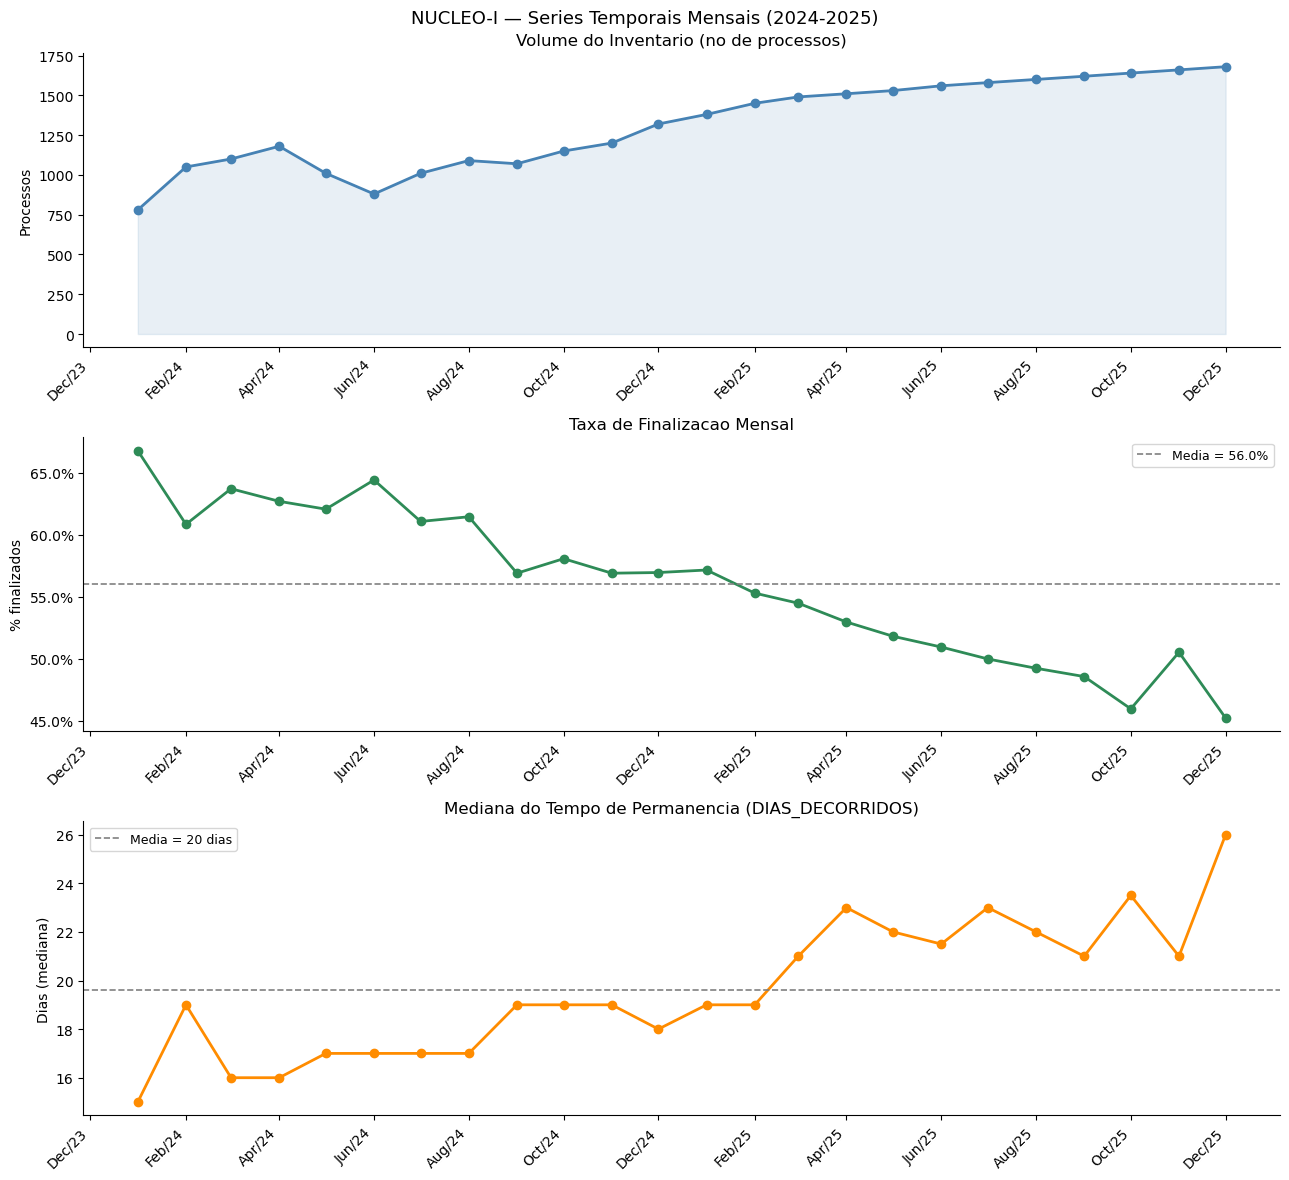

In [7]:
ts = ts_ij.copy()
fig, axes = plt.subplots(3, 1, figsize=(13, 12))
fig.suptitle('NUCLEO-I — Series Temporais Mensais (2024-2025)', fontsize=13)

axes[0].plot(ts['periodo'], ts['volume'], 'o-', c='steelblue', lw=2, ms=6)
axes[0].fill_between(ts['periodo'], ts['volume'], alpha=0.12, color='steelblue')
axes[0].set_title('Volume do Inventario (no de processos)')
axes[0].set_ylabel('Processos')

axes[1].plot(ts['periodo'], ts['taxa_fin'], 'o-', c='seagreen', lw=2, ms=6)
axes[1].axhline(ts['taxa_fin'].mean(), color='gray', ls='--', lw=1.2,
                label=f"Media = {ts['taxa_fin'].mean():.1%}")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].set_title('Taxa de Finalizacao Mensal')
axes[1].set_ylabel('% finalizados')
axes[1].legend(fontsize=9)

axes[2].plot(ts['periodo'], ts['dias_mediana'], 'o-', c='darkorange', lw=2, ms=6)
axes[2].axhline(ts['dias_mediana'].mean(), color='gray', ls='--', lw=1.2,
                label=f"Media = {ts['dias_mediana'].mean():.0f} dias")
axes[2].set_title('Mediana do Tempo de Permanencia (DIAS_DECORRIDOS)')
axes[2].set_ylabel('Dias (mediana)')
axes[2].legend(fontsize=9)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
S('cao_ij_series_temporais')
plt.show()

In [8]:
# ─── DESCRIÇÃO TEXTUAL DO GRÁFICO: NUCLEO-I Séries Temporais Mensais ──────────
_ts = ts_ij.copy()
print("=" * 72)
print("GRÁFICO  : NUCLEO-I — Séries Temporais Mensais (2024–2025)")
print("Arquivo  : cao_ij_series_temporais.png")
print("Tipo     : Gráfico de linhas com marcadores circulares")
print("Layout   : 3 painéis empilhados verticalmente (figura 13×12 pol.)")
print("Período  : Jan/2024 a Dez/2025 — 24 observações mensais")
print("Fonte    : inventario_sintetico.parquet | Filtro: CAO = 'NUCLEO-I'")
print("=" * 72)
print()

# ── PAINEL 1: Volume do Inventário ───────────────────────────────────────────
_vol = _ts['volume']
print("PAINEL 1 ─ VOLUME DO INVENTÁRIO (nº de processos no estoque mensal)")
print(f"  Eixo X : Período mensal (tick a cada 2 meses, rótulos rotacionados 45°)")
print(f"  Eixo Y : Número de processos")
print(f"  Estilo : linha azul-aço (steelblue, lw=2, ms=6) + área semitransparente (alpha=0.12)")
print(f"  Escala : Y mín={_vol.min():.0f}  Y máx={_vol.max():.0f}  amplitude={_vol.max()-_vol.min():.0f} processos")
print()
print(f"  {'Período':<10} {'Volume':>8}  {'Δ mensal':>10}")
print(f"  {'-'*30}")
_prev = None
for _, r in _ts.iterrows():
    delta = f"{r['volume']-_prev:+.0f}" if _prev is not None else "      —"
    print(f"  {r['periodo'].strftime('%b/%Y'):<10} {r['volume']:>8.0f}  {delta:>10}")
    _prev = r['volume']
print()
print(f"  Estatísticas descritivas:")
print(f"    Média    = {_vol.mean():.0f} processos/mês")
print(f"    Mediana  = {_vol.median():.0f} processos/mês")
print(f"    DP       = {_vol.std():.0f}  |  CV = {_vol.std()/_vol.mean():.1%}")
print(f"    Mín      = {_vol.min():.0f} ({_ts.loc[_vol.idxmin(),'periodo'].strftime('%b/%Y')})")
print(f"    Máx      = {_vol.max():.0f} ({_ts.loc[_vol.idxmax(),'periodo'].strftime('%b/%Y')})")
print()

# ── PAINEL 2: Taxa de Finalização ────────────────────────────────────────────
_tf = _ts['taxa_fin']
print("PAINEL 2 ─ TAXA DE FINALIZAÇÃO MENSAL (finalizados / total do estoque)")
print(f"  Eixo X : Período mensal")
print(f"  Eixo Y : Proporção (formato %; eixo formatado como PercentFormatter)")
print(f"  Estilo : linha verde-mar (seagreen, lw=2, ms=6)")
print(f"  Linha de referência (traço cinza): média = {_tf.mean():.1%}")
print(f"  Escala : Y mín={_tf.min():.1%}  Y máx={_tf.max():.1%}")
print()
print(f"  {'Período':<10} {'Taxa_fin':>10} {'Finalizados':>12} {'Volume':>8}")
print(f"  {'-'*42}")
for _, r in _ts.iterrows():
    print(f"  {r['periodo'].strftime('%b/%Y'):<10} {r['taxa_fin']:>10.1%} "
          f"{r['finalizados']:>12.0f} {r['volume']:>8.0f}")
print()
print(f"  Estatísticas descritivas:")
print(f"    Média    = {_tf.mean():.1%}")
print(f"    Mediana  = {_tf.median():.1%}")
print(f"    DP       = {_tf.std():.1%}  |  CV = {_tf.std()/_tf.mean():.1%}")
print(f"    Mín      = {_tf.min():.1%} ({_ts.loc[_tf.idxmin(),'periodo'].strftime('%b/%Y')})")
print(f"    Máx      = {_tf.max():.1%} ({_ts.loc[_tf.idxmax(),'periodo'].strftime('%b/%Y')})")
print()

# ── PAINEL 3: Mediana do Tempo de Permanência ────────────────────────────────
_dm = _ts['dias_mediana']
print("PAINEL 3 ─ MEDIANA DO TEMPO DE PERMANÊNCIA (DIAS_DECORRIDOS mensal)")
print(f"  Eixo X : Período mensal")
print(f"  Eixo Y : Dias (mediana do estoque naquele mês)")
print(f"  Estilo : linha laranja-escuro (darkorange, lw=2, ms=6)")
print(f"  Linha de referência (traço cinza): média das medianas = {_dm.mean():.0f} dias")
print(f"  Escala : Y mín={_dm.min():.0f} dias  Y máx={_dm.max():.0f} dias")
print()
print(f"  {'Período':<10} {'Mediana(dias)':>14}")
print(f"  {'-'*25}")
for _, r in _ts.iterrows():
    print(f"  {r['periodo'].strftime('%b/%Y'):<10} {r['dias_mediana']:>14.0f}")
print()
print(f"  Estatísticas descritivas:")
print(f"    Média das medianas  = {_dm.mean():.0f} dias")
print(f"    Mediana das medianas = {_dm.median():.0f} dias")
print(f"    DP                  = {_dm.std():.0f} dias")
print(f"    Mín = {_dm.min():.0f} dias ({_ts.loc[_dm.idxmin(),'periodo'].strftime('%b/%Y')})")
print(f"    Máx = {_dm.max():.0f} dias ({_ts.loc[_dm.idxmax(),'periodo'].strftime('%b/%Y')})")
print("=" * 72)

GRÁFICO  : NUCLEO-I — Séries Temporais Mensais (2024–2025)
Arquivo  : cao_ij_series_temporais.png
Tipo     : Gráfico de linhas com marcadores circulares
Layout   : 3 painéis empilhados verticalmente (figura 13×12 pol.)
Período  : Jan/2024 a Dez/2025 — 24 observações mensais
Fonte    : inventario_sintetico.parquet | Filtro: CAO = 'NUCLEO-I'

PAINEL 1 ─ VOLUME DO INVENTÁRIO (nº de processos no estoque mensal)
  Eixo X : Período mensal (tick a cada 2 meses, rótulos rotacionados 45°)
  Eixo Y : Número de processos
  Estilo : linha azul-aço (steelblue, lw=2, ms=6) + área semitransparente (alpha=0.12)
  Escala : Y mín=780  Y máx=1680  amplitude=900 processos

  Período      Volume    Δ mensal
  ------------------------------
  Jan/2024        780           —
  Feb/2024       1050        +270
  Mar/2024       1100         +50
  Apr/2024       1180         +80
  May/2024       1010        -170
  Jun/2024        880        -130
  Jul/2024       1010        +130
  Aug/2024       1090         +80

  Salvo: AED_inventario_graficos/cao_ij_atuacao.png


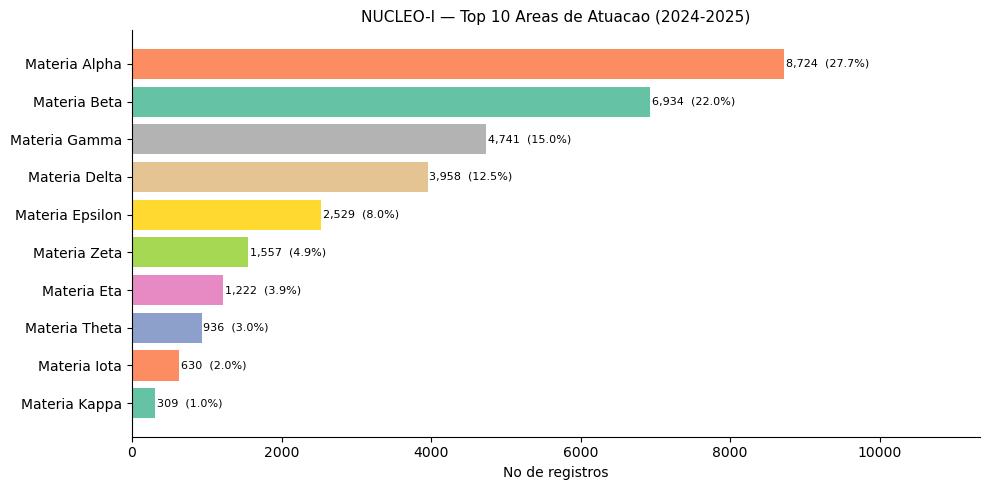

In [9]:
atu_sorted = atu_ij.sort_values('n', ascending=True)
lbls  = [textwrap.fill(str(a), 32) for a in atu_sorted['ATUACAO']]
total = len(det_ij)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(lbls, atu_sorted['n'], color=CORES[:len(atu_sorted)])
for bar, v in zip(bars, atu_sorted['n']):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{v:,}  ({v/total:.1%})', va='center', fontsize=8)
ax.set_title('NUCLEO-I — Top 10 Areas de Atuacao (2024-2025)', fontsize=11)
ax.set_xlabel('No de registros')
ax.set_xlim(0, atu_sorted['n'].max() * 1.3)
plt.tight_layout()
S('cao_ij_atuacao')
plt.show()

In [10]:
# ─── DESCRIÇÃO TEXTUAL DO GRÁFICO: NUCLEO-I Top 10 Áreas de Atuação ───────────
_atu_ij_s = atu_ij.sort_values('n', ascending=False).reset_index(drop=True)
_total_ij = len(det_ij)
print("=" * 72)
print("GRÁFICO  : NUCLEO-I — Top 10 Áreas de Atuação (2024–2025)")
print("Arquivo  : cao_ij_atuacao.png")
print("Tipo     : Gráfico de barras horizontais (barh)")
print("Layout   : Figura 10×5 pol. | Barras ordenadas da menor para a maior (ascending)")
print("Eixo X   : Número de registros (escala absoluta)")
print("Eixo Y   : Categoria temática (coluna ATUACAO)")
print(f"Universo : {_total_ij:,} registros totais (NUCLEO-I, 2024–2025)")
print("Anotação : valor absoluto e % exibidos à direita de cada barra")
print("=" * 72)
print()
print(f"  {'#':<3} {'Área de Atuação':<42} {'n':>7} {'%':>7}")
print(f"  {'-'*62}")
for _i, _r in _atu_ij_s.iterrows():
    print(f"  {_i+1:<3} {str(_r['ATUACAO'])[:42]:<42} {_r['n']:>7,} {_r['n']/_total_ij:>7.1%}")
print()
print(f"  Top 10 somam: {_atu_ij_s['n'].sum():,} registros ({_atu_ij_s['n'].sum()/_total_ij:.1%} do total NUCLEO-I)")
print(f"  Escala X   : 0 até {int(_atu_ij_s['n'].max() * 1.3):,} (máximo + margem de 30%)")
print("=" * 72)

GRÁFICO  : NUCLEO-I — Top 10 Áreas de Atuação (2024–2025)
Arquivo  : cao_ij_atuacao.png
Tipo     : Gráfico de barras horizontais (barh)
Layout   : Figura 10×5 pol. | Barras ordenadas da menor para a maior (ascending)
Eixo X   : Número de registros (escala absoluta)
Eixo Y   : Categoria temática (coluna ATUACAO)
Universo : 31,540 registros totais (NUCLEO-I, 2024–2025)
Anotação : valor absoluto e % exibidos à direita de cada barra

  #   Área de Atuação                                  n       %
  --------------------------------------------------------------
  1   Materia Alpha                                8,724   27.7%
  2   Materia Beta                                 6,934   22.0%
  3   Materia Gamma                                4,741   15.0%
  4   Materia Delta                                3,958   12.5%
  5   Materia Epsilon                              2,529    8.0%
  6   Materia Zeta                                 1,557    4.9%
  7   Materia Eta                             

  Salvo: AED_inventario_graficos/cao_ij_tipo_classe_dias.png


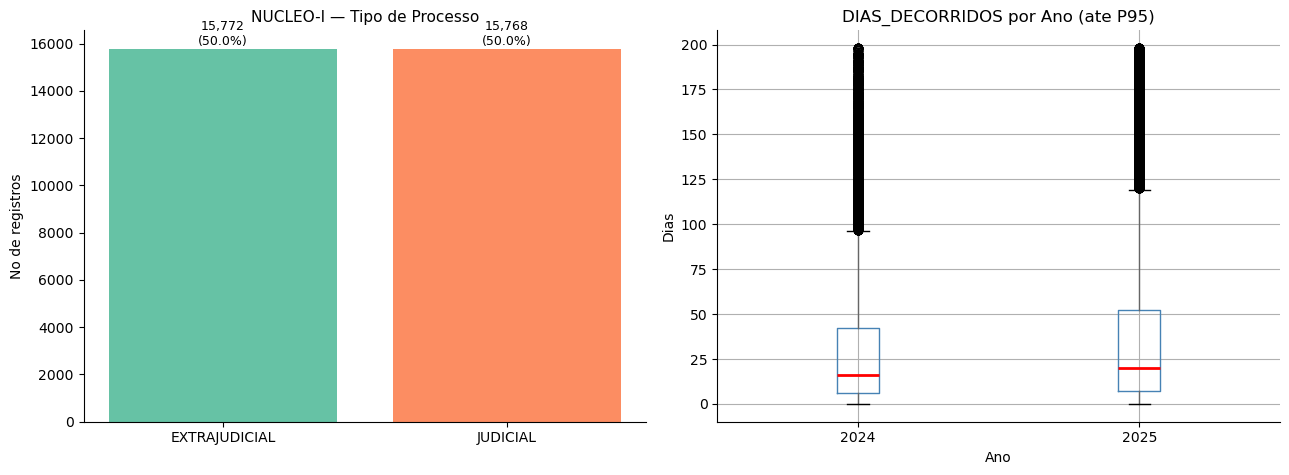

NUCLEO-I — DIAS_DECORRIDOS por ano:
        count  mean   std  min  25%   50%   75%    90%    max
ano                                                          
2024  12840.0  44.6  70.0  0.0  6.0  17.0  49.0  123.0  770.0
2025  18700.0  51.1  73.2  0.0  7.0  22.0  63.0  143.0  799.0


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

tc = det_ij['TIPO_CLASSE'].value_counts()
bars = axes[0].bar(tc.index, tc.values, color=CORES[:len(tc)])
axes[0].set_title('NUCLEO-I — Tipo de Processo', fontsize=11)
axes[0].set_ylabel('No de registros')
for bar, (k, v) in zip(bars, tc.items()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{v:,}\n({v/len(det_ij):.1%})', ha='center', va='bottom', fontsize=9)

det_ij_plot = det_ij.copy()
det_ij_plot['Ano'] = det_ij_plot['ano'].astype(str)
cap = det_ij_plot['dias'].quantile(.95)
det_ij_plot[det_ij_plot['dias'] <= cap].boxplot(
    column='dias', by='Ano', ax=axes[1],
    boxprops=dict(color='steelblue'),
    medianprops=dict(color='red', lw=2))
axes[1].set_title('DIAS_DECORRIDOS por Ano (ate P95)')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Dias')
plt.suptitle('')
plt.tight_layout()
S('cao_ij_tipo_classe_dias')
plt.show()

print('NUCLEO-I — DIAS_DECORRIDOS por ano:')
print(det_ij.groupby('ano')['dias'].describe(percentiles=[.25, .5, .75, .9]).round(1))

In [12]:
# ─── DESCRIÇÃO TEXTUAL DO GRÁFICO: NUCLEO-I Tipo de Processo + DIAS_DECORRIDOS ─
_tc_ij = det_ij['TIPO_CLASSE'].value_counts()
_cap_ij = det_ij['dias'].quantile(.95)
print("=" * 72)
print("GRÁFICO  : NUCLEO-I — Tipo de Processo | DIAS_DECORRIDOS por Ano")
print("Arquivo  : cao_ij_tipo_classe_dias.png")
print("Tipo     : Dois painéis lado a lado (1×2) | Figura 13×5 pol.")
print("=" * 72)
print()

print("PAINEL ESQUERDO ─ TIPO DE PROCESSO (barras verticais)")
print(f"  Eixo X : Categorias de TIPO_CLASSE")
print(f"  Eixo Y : Número de registros")
print(f"  Anotação: valor absoluto e % acima de cada barra")
print()
print(f"  {'Tipo':<20} {'n':>10} {'%':>8}")
print(f"  {'-'*40}")
for _cat, _cnt in _tc_ij.items():
    print(f"  {str(_cat):<20} {_cnt:>10,} {_cnt/len(det_ij):>8.1%}")
print()

print("PAINEL DIREITO ─ DIAS_DECORRIDOS POR ANO (boxplot)")
print(f"  Eixo X : Ano de referência (2024, 2025)")
print(f"  Eixo Y : Dias decorridos")
print(f"  Filtro visual: cap no P95 = {_cap_ij:.0f} dias (outliers extremos excluídos do plot)")
print(f"  Estilo : caixas azul-aço (boxprops), mediana vermelha (lw=2)")
print()
for _ano in [2024, 2025]:
    _d     = det_ij.loc[det_ij['ano'] == _ano, 'dias'].dropna()
    _d_cap = _d[_d <= _cap_ij]
    print(f"  Ano {_ano}  (n total={len(_d):,} | n após cap P95={len(_d_cap):,}):")
    print(f"    Mínimo   = {_d_cap.min():.0f} dias")
    print(f"    P25      = {_d_cap.quantile(.25):.0f} dias")
    print(f"    Mediana  = {_d_cap.median():.0f} dias   ← linha vermelha no boxplot")
    print(f"    Média    = {_d_cap.mean():.0f} dias")
    print(f"    P75      = {_d_cap.quantile(.75):.0f} dias")
    print(f"    Máx (cap)= {_d_cap.max():.0f} dias  |  P95 original = {_d.quantile(.95):.0f} dias")
    print(f"    P90 orig = {_d.quantile(.90):.0f} dias")
    print()
print("=" * 72)
print("DADOS TABULARES COMPLEMENTARES — describe() sem cap (todos os registros):")
print(det_ij.groupby('ano')['dias'].describe(percentiles=[.25, .5, .75, .9]).round(1).to_string())
print("=" * 72)

GRÁFICO  : NUCLEO-I — Tipo de Processo | DIAS_DECORRIDOS por Ano
Arquivo  : cao_ij_tipo_classe_dias.png
Tipo     : Dois painéis lado a lado (1×2) | Figura 13×5 pol.

PAINEL ESQUERDO ─ TIPO DE PROCESSO (barras verticais)
  Eixo X : Categorias de TIPO_CLASSE
  Eixo Y : Número de registros
  Anotação: valor absoluto e % acima de cada barra

  Tipo                          n        %
  ----------------------------------------
  EXTRAJUDICIAL            15,772    50.0%
  JUDICIAL                 15,768    50.0%

PAINEL DIREITO ─ DIAS_DECORRIDOS POR ANO (boxplot)
  Eixo X : Ano de referência (2024, 2025)
  Eixo Y : Dias decorridos
  Filtro visual: cap no P95 = 198 dias (outliers extremos excluídos do plot)
  Estilo : caixas azul-aço (boxprops), mediana vermelha (lw=2)

  Ano 2024  (n total=12,840 | n após cap P95=12,254):
    Mínimo   = 0 dias
    P25      = 6 dias
    Mediana  = 16 dias   ← linha vermelha no boxplot
    Média    = 33 dias
    P75      = 42 dias
    Máx (cap)= 198 dias  |  P

---
## 2. Análise Exploratória — NUCLEO-II

**Contexto:** O NUCLEO-II atua em procedimentos predominantemente investigatórios e extrajudiciais (~93%), o que explica:
- Baixa taxa de finalização (~20%): processos investigativos têm ciclo de vida longo
- Domínio de procedimentos extrajudiciais (>90% dos registros)

**Atenção especial:** volume menor (~170/mês) gera maior variabilidade percentual, tornando o monitoramento estatístico especialmente relevante.

In [13]:
n_g   = len(det_gaeco)
fin_g = det_gaeco['finalizado'].sum()
jud_g = (det_gaeco['TIPO_CLASSE'] == 'JUDICIAL').sum()

print('=' * 52)
print('  NUCLEO-II  |  2024-2025')
print('=' * 52)
print(f'  Registros no inventario : {n_g:>10,}')
print(f'  Finalizados             : {fin_g:>10,}  ({fin_g/n_g:.1%})')
print(f'  Pendentes               : {n_g-fin_g:>10,}  ({1-fin_g/n_g:.1%})')
print(f'  Judiciais               : {jud_g:>10,}  ({jud_g/n_g:.1%})')
print(f'  Extrajudiciais          : {n_g-jud_g:>10,}  ({1-jud_g/n_g:.1%})')
print('-' * 52)
print('  DIAS_DECORRIDOS:')
for lab, val in [('Mediana', det_gaeco['dias'].median()),
                  ('Media',   det_gaeco['dias'].mean()),
                  ('P75',     det_gaeco['dias'].quantile(.75)),
                  ('P90',     det_gaeco['dias'].quantile(.90))]:
    print(f'    {lab:<10}: {val:>8.0f} dias')
print('=' * 52)

print()
print('Distribuicao por unidade NUCLEO-II:')
gaeco_org = con.execute(
    'SELECT NOME_ORGAO, COUNT(*) AS n,'
    "       SUM(CASE WHEN DATA_FINALIZACAO IS NOT NULL AND DATA_FINALIZACAO != ''"
    '           THEN 1 ELSE 0 END) AS fin'
    "  FROM " + PARQUET +
    "  WHERE CAO = 'NUCLEO-II'"
    '    AND ANO_REFERENCIA IN (2024, 2025)'
    '  GROUP BY NOME_ORGAO ORDER BY n DESC'
).df()
gaeco_org['taxa_fin'] = (gaeco_org['fin'] / gaeco_org['n']).map('{:.1%}'.format)
print(gaeco_org.to_string(index=False))

  NUCLEO-II  |  2024-2025
  Registros no inventario :      4,063
  Finalizados             :        825  (20.3%)
  Pendentes               :      3,238  (79.7%)
  Judiciais               :        278  (6.8%)
  Extrajudiciais          :      3,785  (93.2%)
----------------------------------------------------
  DIAS_DECORRIDOS:
    Mediana   :      482 dias
    Media     :      751 dias
    P75       :     1016 dias
    P90       :     1802 dias

Distribuicao por unidade NUCLEO-II:
NOME_ORGAO    n   fin taxa_fin
 UNIDADE-B 4063 825.0    20.3%


  Salvo: AED_inventario_graficos/gaeco_series_temporais.png


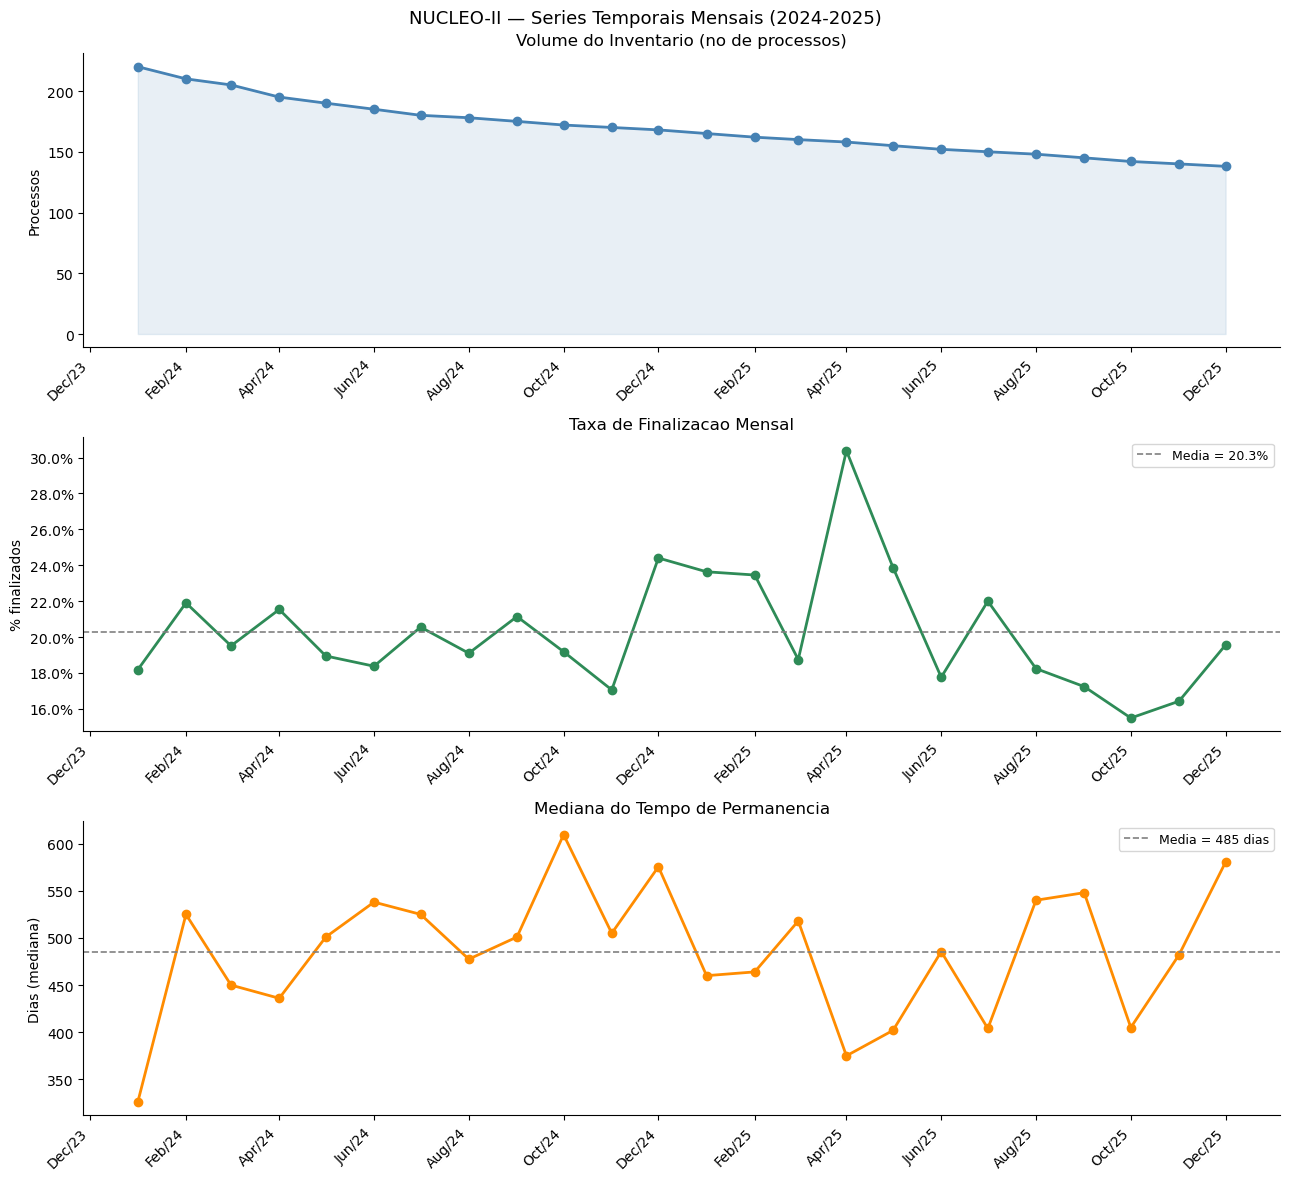

In [14]:
ts = ts_gaeco.copy()
fig, axes = plt.subplots(3, 1, figsize=(13, 12))
fig.suptitle('NUCLEO-II — Series Temporais Mensais (2024-2025)', fontsize=13)

axes[0].plot(ts['periodo'], ts['volume'], 'o-', c='steelblue', lw=2, ms=6)
axes[0].fill_between(ts['periodo'], ts['volume'], alpha=0.12, color='steelblue')
axes[0].set_title('Volume do Inventario (no de processos)')
axes[0].set_ylabel('Processos')

axes[1].plot(ts['periodo'], ts['taxa_fin'], 'o-', c='seagreen', lw=2, ms=6)
axes[1].axhline(ts['taxa_fin'].mean(), color='gray', ls='--', lw=1.2,
                label=f"Media = {ts['taxa_fin'].mean():.1%}")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].set_title('Taxa de Finalizacao Mensal')
axes[1].set_ylabel('% finalizados')
axes[1].legend(fontsize=9)

axes[2].plot(ts['periodo'], ts['dias_mediana'], 'o-', c='darkorange', lw=2, ms=6)
axes[2].axhline(ts['dias_mediana'].mean(), color='gray', ls='--', lw=1.2,
                label=f"Media = {ts['dias_mediana'].mean():.0f} dias")
axes[2].set_title('Mediana do Tempo de Permanencia')
axes[2].set_ylabel('Dias (mediana)')
axes[2].legend(fontsize=9)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
S('gaeco_series_temporais')
plt.show()

In [15]:
# ─── DESCRIÇÃO TEXTUAL DO GRÁFICO: NUCLEO-II Séries Temporais Mensais ────────────
_ts = ts_gaeco.copy()
print("=" * 72)
print("GRÁFICO  : NUCLEO-II — Séries Temporais Mensais (2024–2025)")
print("Arquivo  : gaeco_series_temporais.png")
print("Tipo     : Gráfico de linhas com marcadores circulares")
print("Layout   : 3 painéis empilhados verticalmente (figura 13×12 pol.)")
print("Período  : Jan/2024 a Dez/2025 — 24 observações mensais")
print("Fonte    : inventario_sintetico.parquet | Filtro: CAO='NUCLEO-II'")
print("=" * 72)
print()

# ── PAINEL 1: Volume do Inventário ───────────────────────────────────────────
_vol = _ts['volume']
print("PAINEL 1 ─ VOLUME DO INVENTÁRIO (nº de processos no estoque mensal)")
print(f"  Eixo X : Período mensal (tick a cada 2 meses, rótulos rotacionados 45°)")
print(f"  Eixo Y : Número de processos")
print(f"  Estilo : linha azul-aço (steelblue, lw=2, ms=6) + área semitransparente (alpha=0.12)")
print(f"  Escala : Y mín={_vol.min():.0f}  Y máx={_vol.max():.0f}  amplitude={_vol.max()-_vol.min():.0f} processos")
print()
print(f"  {'Período':<10} {'Volume':>8}  {'Δ mensal':>10}")
print(f"  {'-'*30}")
_prev = None
for _, r in _ts.iterrows():
    delta = f"{r['volume']-_prev:+.0f}" if _prev is not None else "      —"
    print(f"  {r['periodo'].strftime('%b/%Y'):<10} {r['volume']:>8.0f}  {delta:>10}")
    _prev = r['volume']
print()
print(f"  Estatísticas descritivas:")
print(f"    Média    = {_vol.mean():.0f} processos/mês")
print(f"    Mediana  = {_vol.median():.0f} processos/mês")
print(f"    DP       = {_vol.std():.0f}  |  CV = {_vol.std()/_vol.mean():.1%}")
print(f"    Mín      = {_vol.min():.0f} ({_ts.loc[_vol.idxmin(),'periodo'].strftime('%b/%Y')})")
print(f"    Máx      = {_vol.max():.0f} ({_ts.loc[_vol.idxmax(),'periodo'].strftime('%b/%Y')})")
print()

# ── PAINEL 2: Taxa de Finalização ────────────────────────────────────────────
_tf = _ts['taxa_fin']
print("PAINEL 2 ─ TAXA DE FINALIZAÇÃO MENSAL (finalizados / total do estoque)")
print(f"  Eixo X : Período mensal")
print(f"  Eixo Y : Proporção (formato %; eixo formatado como PercentFormatter)")
print(f"  Estilo : linha verde-mar (seagreen, lw=2, ms=6)")
print(f"  Linha de referência (traço cinza): média = {_tf.mean():.1%}")
print(f"  Escala : Y mín={_tf.min():.1%}  Y máx={_tf.max():.1%}")
print()
print(f"  {'Período':<10} {'Taxa_fin':>10} {'Finalizados':>12} {'Volume':>8}")
print(f"  {'-'*42}")
for _, r in _ts.iterrows():
    print(f"  {r['periodo'].strftime('%b/%Y'):<10} {r['taxa_fin']:>10.1%} "
          f"{r['finalizados']:>12.0f} {r['volume']:>8.0f}")
print()
print(f"  Estatísticas descritivas:")
print(f"    Média    = {_tf.mean():.1%}")
print(f"    Mediana  = {_tf.median():.1%}")
print(f"    DP       = {_tf.std():.1%}  |  CV = {_tf.std()/_tf.mean():.1%}")
print(f"    Mín      = {_tf.min():.1%} ({_ts.loc[_tf.idxmin(),'periodo'].strftime('%b/%Y')})")
print(f"    Máx      = {_tf.max():.1%} ({_ts.loc[_tf.idxmax(),'periodo'].strftime('%b/%Y')})")
print()

# ── PAINEL 3: Mediana do Tempo de Permanência ────────────────────────────────
_dm = _ts['dias_mediana']
print("PAINEL 3 ─ MEDIANA DO TEMPO DE PERMANÊNCIA (DIAS_DECORRIDOS mensal)")
print(f"  Eixo X : Período mensal")
print(f"  Eixo Y : Dias (mediana do estoque naquele mês)")
print(f"  Estilo : linha laranja-escuro (darkorange, lw=2, ms=6)")
print(f"  Linha de referência (traço cinza): média das medianas = {_dm.mean():.0f} dias")
print(f"  Escala : Y mín={_dm.min():.0f} dias  Y máx={_dm.max():.0f} dias")
print()
print(f"  {'Período':<10} {'Mediana(dias)':>14}")
print(f"  {'-'*25}")
for _, r in _ts.iterrows():
    print(f"  {r['periodo'].strftime('%b/%Y'):<10} {r['dias_mediana']:>14.0f}")
print()
print(f"  Estatísticas descritivas:")
print(f"    Média das medianas   = {_dm.mean():.0f} dias")
print(f"    Mediana das medianas = {_dm.median():.0f} dias")
print(f"    DP                   = {_dm.std():.0f} dias")
print(f"    Mín = {_dm.min():.0f} dias ({_ts.loc[_dm.idxmin(),'periodo'].strftime('%b/%Y')})")
print(f"    Máx = {_dm.max():.0f} dias ({_ts.loc[_dm.idxmax(),'periodo'].strftime('%b/%Y')})")
print("=" * 72)

GRÁFICO  : NUCLEO-II — Séries Temporais Mensais (2024–2025)
Arquivo  : gaeco_series_temporais.png
Tipo     : Gráfico de linhas com marcadores circulares
Layout   : 3 painéis empilhados verticalmente (figura 13×12 pol.)
Período  : Jan/2024 a Dez/2025 — 24 observações mensais
Fonte    : inventario_sintetico.parquet | Filtro: CAO='NUCLEO-II'

PAINEL 1 ─ VOLUME DO INVENTÁRIO (nº de processos no estoque mensal)
  Eixo X : Período mensal (tick a cada 2 meses, rótulos rotacionados 45°)
  Eixo Y : Número de processos
  Estilo : linha azul-aço (steelblue, lw=2, ms=6) + área semitransparente (alpha=0.12)
  Escala : Y mín=138  Y máx=220  amplitude=82 processos

  Período      Volume    Δ mensal
  ------------------------------
  Jan/2024        220           —
  Feb/2024        210         -10
  Mar/2024        205          -5
  Apr/2024        195         -10
  May/2024        190          -5
  Jun/2024        185          -5
  Jul/2024        180          -5
  Aug/2024        178          -2
  

  Salvo: AED_inventario_graficos/gaeco_atuacao_tipo_classe.png


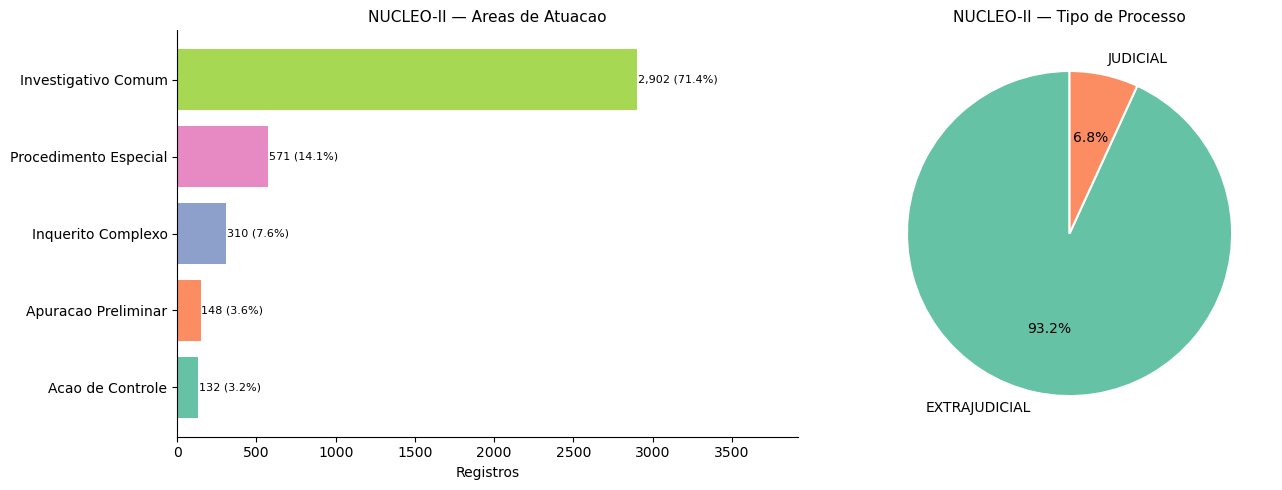

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

atu_s = atu_gaeco.sort_values('n', ascending=True)
lbls  = [textwrap.fill(str(a), 30) for a in atu_s['ATUACAO']]
bars  = axes[0].barh(lbls, atu_s['n'], color=CORES[:len(atu_s)])
for bar, v in zip(bars, atu_s['n']):
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f'{v:,} ({v/n_g:.1%})', va='center', fontsize=8)
axes[0].set_title('NUCLEO-II — Areas de Atuacao', fontsize=11)
axes[0].set_xlabel('Registros')
axes[0].set_xlim(0, atu_s['n'].max() * 1.35)

tc_g = det_gaeco['TIPO_CLASSE'].value_counts()
axes[1].pie(tc_g.values, labels=tc_g.index,
            autopct='%1.1f%%', colors=CORES[:len(tc_g)],
            wedgeprops=dict(edgecolor='white', linewidth=1.5),
            startangle=90)
axes[1].set_title('NUCLEO-II — Tipo de Processo', fontsize=11)

plt.tight_layout()
S('gaeco_atuacao_tipo_classe')
plt.show()

In [17]:
# ─── DESCRIÇÃO TEXTUAL DO GRÁFICO: NUCLEO-II Áreas de Atuação + Tipo de Processo ─
_atu_g_s = atu_gaeco.sort_values('n', ascending=False).reset_index(drop=True)
_tc_g    = det_gaeco['TIPO_CLASSE'].value_counts()
print("=" * 72)
print("GRÁFICO  : NUCLEO-II — Áreas de Atuação | Tipo de Processo")
print("Arquivo  : gaeco_atuacao_tipo_classe.png")
print("Tipo     : Dois painéis lado a lado (1×2) | Figura 14×5 pol.")
print("=" * 72)
print()

print("PAINEL ESQUERDO ─ ÁREAS DE ATUAÇÃO (barras horizontais, Top 10)")
print(f"  Eixo X : Número de registros (escala absoluta)")
print(f"  Eixo Y : Categoria temática (coluna ATUACAO) — texto com quebra de linha (wrap=30)")
print(f"  Escala X: 0 até {int(_atu_g_s['n'].max() * 1.35):,} (máximo + margem de 35%)")
print(f"  Universo: {n_g:,} registros (NUCLEO-II, 2024–2025)")
print(f"  Anotação: valor absoluto e % à direita de cada barra")
print()
print(f"  {'#':<3} {'Área de Atuação':<38} {'n':>7} {'%':>7}")
print(f"  {'-'*58}")
for _i, _r in _atu_g_s.iterrows():
    print(f"  {_i+1:<3} {str(_r['ATUACAO'])[:38]:<38} {_r['n']:>7,} {_r['n']/n_g:>7.1%}")
print()
print(f"  Top {len(_atu_g_s)} somam: {_atu_g_s['n'].sum():,} ({_atu_g_s['n'].sum()/n_g:.1%} do total NUCLEO-II)")
print()

print("PAINEL DIREITO ─ TIPO DE PROCESSO (gráfico de pizza/torta)")
print(f"  Estilo : ângulo inicial 90°, bordas brancas entre fatias (linewidth=1.5)")
print(f"  Anotação: percentual (1 casa decimal) dentro de cada fatia")
print()
print(f"  {'Tipo':<20} {'n':>10} {'%':>8}")
print(f"  {'-'*40}")
for _cat, _cnt in _tc_g.items():
    print(f"  {str(_cat):<20} {_cnt:>10,} {_cnt/n_g:>8.1%}")
print("=" * 72)

GRÁFICO  : NUCLEO-II — Áreas de Atuação | Tipo de Processo
Arquivo  : gaeco_atuacao_tipo_classe.png
Tipo     : Dois painéis lado a lado (1×2) | Figura 14×5 pol.

PAINEL ESQUERDO ─ ÁREAS DE ATUAÇÃO (barras horizontais, Top 10)
  Eixo X : Número de registros (escala absoluta)
  Eixo Y : Categoria temática (coluna ATUACAO) — texto com quebra de linha (wrap=30)
  Escala X: 0 até 3,917 (máximo + margem de 35%)
  Universo: 4,063 registros (NUCLEO-II, 2024–2025)
  Anotação: valor absoluto e % à direita de cada barra

  #   Área de Atuação                              n       %
  ----------------------------------------------------------
  1   Investigativo Comum                      2,902   71.4%
  2   Procedimento Especial                      571   14.1%
  3   Inquerito Complexo                         310    7.6%
  4   Apuracao Preliminar                        148    3.6%
  5   Acao de Controle                           132    3.2%

  Top 5 somam: 4,063 (100.0% do total NUCLEO-II)

PAINEL

---
## 3. Análise de Séries Temporais

1. **Decomposição STL** *(Cleveland et al., 1990)* — tendência + sazonalidade + resíduo
2. **ACF / PACF** *(Box & Jenkins, 2015)* — estrutura de dependência temporal
3. **Testes formais** — próxima seção

> **Limitação:** n=24 < 25 mínimo para `period=12`. Usa-se `period=6` (semestral), compatível com o recesso forense de janeiro e julho.
> Schwert (1989): n ≥ 50 para ADF com ~80% de poder. Com n=24, poder ~40–50%.

=== NUCLEO-I: Volume Mensal ===
  Salvo: AED_inventario_graficos/cao_ij_stl.png


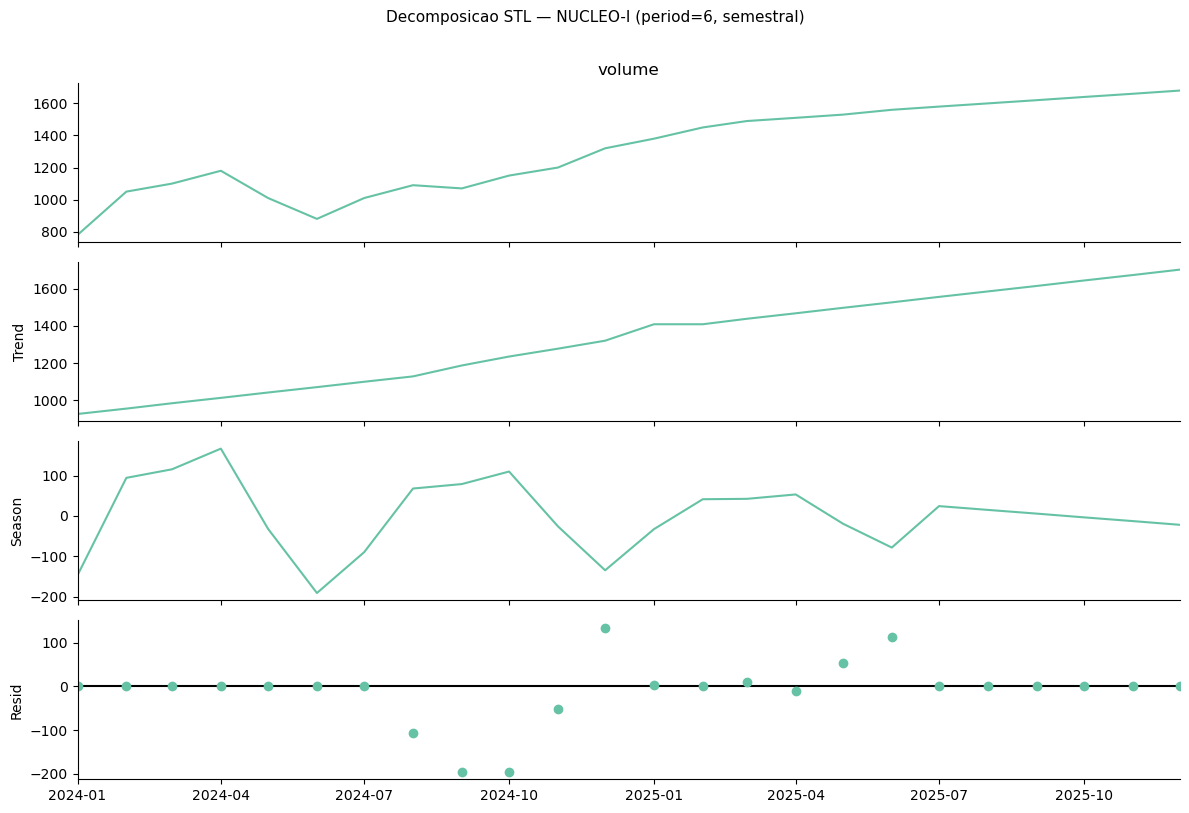

  Variancia explicada — Tendencia: 83.4% | Sazonalidade: 10.0% | Residuo: 7.0%

=== NUCLEO-II: Volume Mensal ===
  Salvo: AED_inventario_graficos/gaeco_stl.png


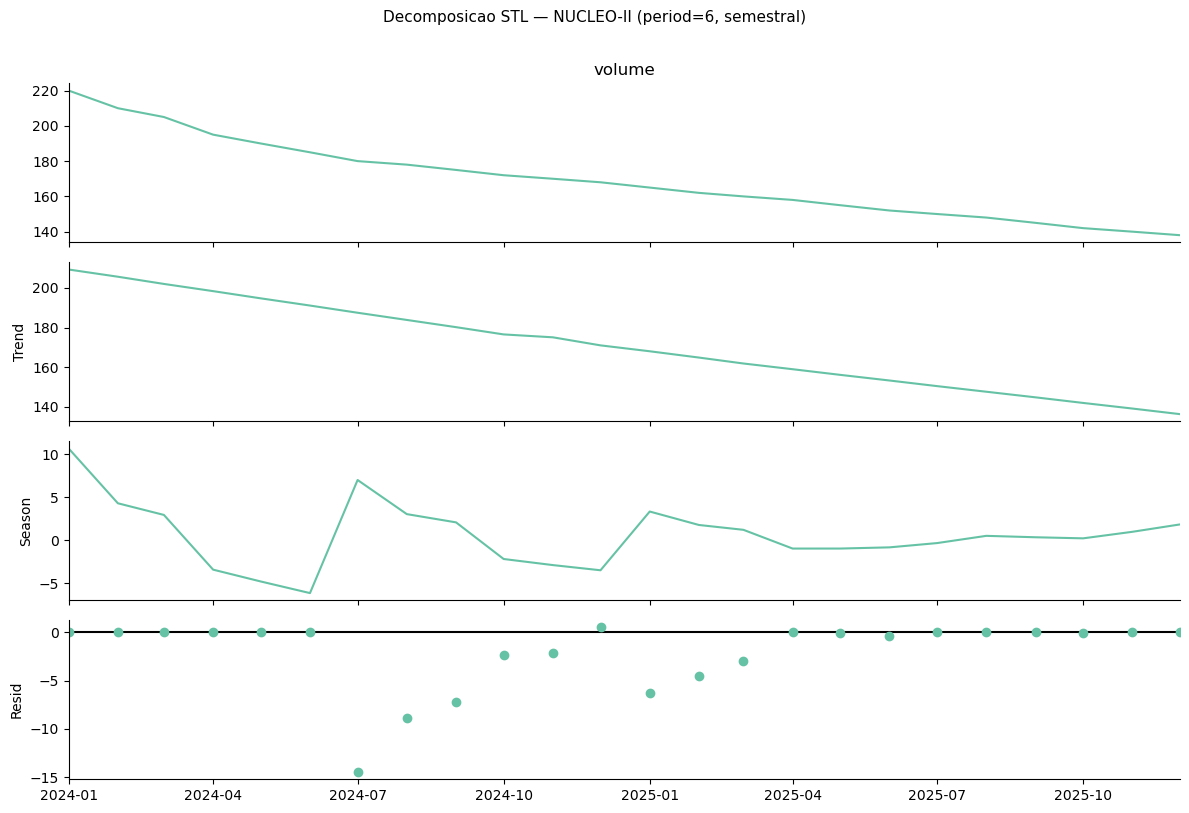

  Variancia explicada — Tendencia: 97.1% | Sazonalidade: 2.6% | Residuo: 2.7%


In [18]:
print('=== NUCLEO-I: Volume Mensal ===')
stl_ij = stl_plot(ts_ij, 'volume', 'NUCLEO-I', salvar_como='cao_ij_stl')
print()
print('=== NUCLEO-II: Volume Mensal ===')
stl_g = stl_plot(ts_gaeco, 'volume', 'NUCLEO-II', salvar_como='gaeco_stl')

In [19]:
# ─── DESCRIÇÃO TEXTUAL DOS GRÁFICOS: Decomposição STL ────────────────────────
print("=" * 72)
print("GRÁFICOS : Decomposição STL — NUCLEO-I e NUCLEO-II")
print("Arquivos : cao_ij_stl.png | gaeco_stl.png")
print("Tipo     : Decomposição STL (Seasonal-Trend decomposition via Loess)")
print("Layout   : 4 painéis empilhados por gráfico — figura 12×8 pol.")
print("           Painéis: (1) Série original | (2) Tendência | (3) Sazonalidade | (4) Resíduo")
print("Parâmetros: period=6 (semestral), robust=True")
print("Referência: Cleveland et al. (1990), Journal of Official Statistics")
print("Limitação : n=24 < 25 para period=12; usa-se period=6 (recesso jan/jul)")
print("=" * 72)
print()

for _nome, _ts_df in [('NUCLEO-I', ts_ij), ('NUCLEO-II', ts_gaeco)]:
    _serie = _ts_df.set_index('periodo')['volume'].dropna()
    try:
        from statsmodels.tsa.seasonal import STL as _STL2
        _res2 = _STL2(_serie, period=6, robust=True).fit()
        _vt   = _res2.trend.var()    / _serie.var()
        _vs   = _res2.seasonal.var() / _serie.var()
        _vr   = _res2.resid.var()    / _serie.var()
        print(f"── {_nome} — Série: volume mensal (n={len(_serie)} obs.) ─────────────────")
        print(f"  Escala série original : mín={_serie.min():.0f}  máx={_serie.max():.0f}")
        print(f"  Escala da tendência   : mín={_res2.trend.min():.1f}  máx={_res2.trend.max():.1f}")
        print(f"  Amplitude sazonal     : {_res2.seasonal.min():.1f} a {_res2.seasonal.max():.1f}"
              f"  (range={_res2.seasonal.max()-_res2.seasonal.min():.1f})")
        print(f"  Amplitude do resíduo  : {_res2.resid.min():.1f} a {_res2.resid.max():.1f}")
        print(f"  Variância explicada:")
        print(f"    Tendência   = {_vt:.1%}")
        print(f"    Sazonalidade = {_vs:.1%}")
        print(f"    Resíduo      = {_vr:.1%}")
        print()
        print(f"  {'Período':<10} {'Original':>10} {'Tendência':>11} {'Sazonal':>9} {'Resíduo':>9}")
        print(f"  {'-'*51}")
        for _dt in _serie.index:
            print(f"  {_dt.strftime('%b/%Y'):<10} {_serie[_dt]:>10.0f} "
                  f"{_res2.trend[_dt]:>11.1f} "
                  f"{_res2.seasonal[_dt]:>9.1f} "
                  f"{_res2.resid[_dt]:>9.1f}")
        print()
    except Exception as _e:
        print(f"  {_nome}: não foi possível recalcular STL para descrição ({_e})")
        print()

print("=" * 72)

GRÁFICOS : Decomposição STL — NUCLEO-I e NUCLEO-II
Arquivos : cao_ij_stl.png | gaeco_stl.png
Tipo     : Decomposição STL (Seasonal-Trend decomposition via Loess)
Layout   : 4 painéis empilhados por gráfico — figura 12×8 pol.
           Painéis: (1) Série original | (2) Tendência | (3) Sazonalidade | (4) Resíduo
Parâmetros: period=6 (semestral), robust=True
Referência: Cleveland et al. (1990), Journal of Official Statistics
Limitação : n=24 < 25 para period=12; usa-se period=6 (recesso jan/jul)

── NUCLEO-I — Série: volume mensal (n=24 obs.) ─────────────────
  Escala série original : mín=780  máx=1680
  Escala da tendência   : mín=926.9  máx=1702.2
  Amplitude sazonal     : -191.0 a 166.6  (range=357.7)
  Amplitude do resíduo  : -196.2 a 134.3
  Variância explicada:
    Tendência   = 83.4%
    Sazonalidade = 10.0%
    Resíduo      = 7.0%

  Período      Original   Tendência   Sazonal   Resíduo
  ---------------------------------------------------
  Jan/2024          780       926.9    

  Salvo: AED_inventario_graficos/cao_ij_acf_pacf_volume.png


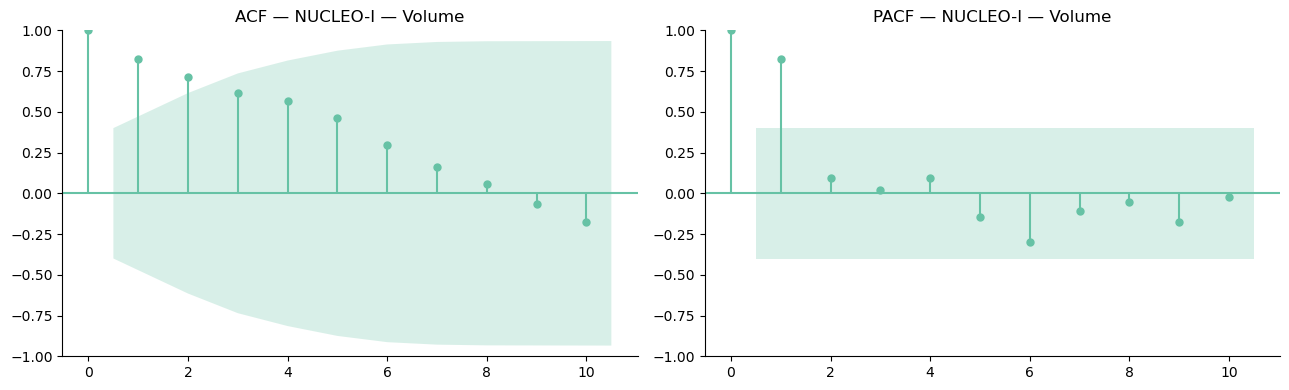

  Salvo: AED_inventario_graficos/gaeco_acf_pacf_volume.png


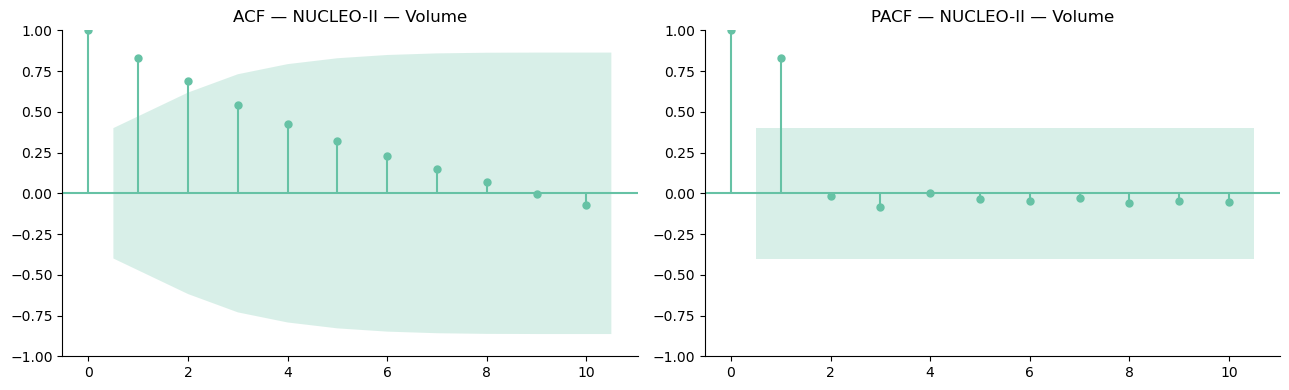

  Salvo: AED_inventario_graficos/cao_ij_acf_pacf_taxa.png


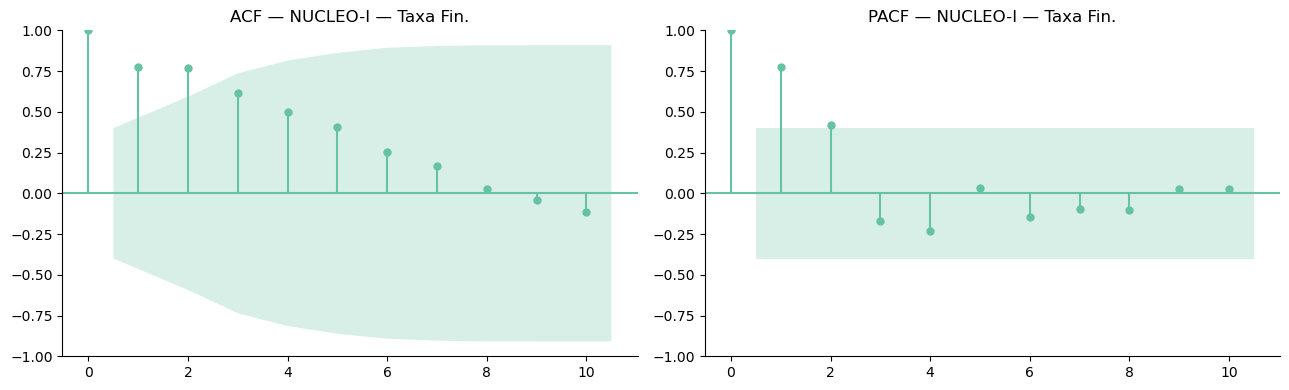

  Salvo: AED_inventario_graficos/gaeco_acf_pacf_taxa.png


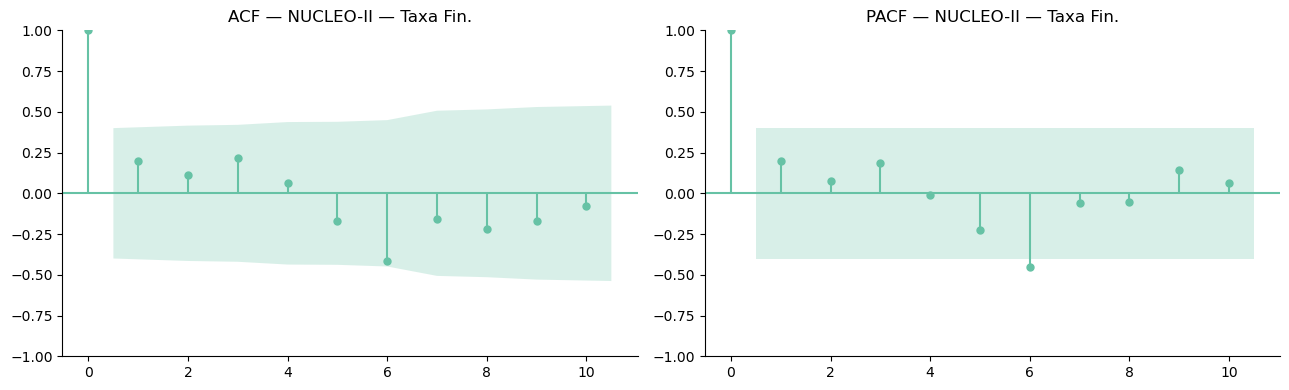

In [20]:
acf_pacf_plot(ts_ij['volume'],    'NUCLEO-I — Volume',    salvar_como='cao_ij_acf_pacf_volume')
acf_pacf_plot(ts_gaeco['volume'], 'NUCLEO-II — Volume',     salvar_como='gaeco_acf_pacf_volume')
acf_pacf_plot(ts_ij['taxa_fin'],  'NUCLEO-I — Taxa Fin.', salvar_como='cao_ij_acf_pacf_taxa')
acf_pacf_plot(ts_gaeco['taxa_fin'],'NUCLEO-II — Taxa Fin.', salvar_como='gaeco_acf_pacf_taxa')

In [21]:
# ─── DESCRIÇÃO TEXTUAL DOS GRÁFICOS: ACF e PACF ──────────────────────────────
from statsmodels.tsa.stattools import acf as _acf_fn, pacf as _pacf_fn

print("=" * 72)
print("GRÁFICOS : ACF e PACF — Estrutura de Dependência Temporal")
print("Arquivos : cao_ij_acf_pacf_volume.png | gaeco_acf_pacf_volume.png")
print("           cao_ij_acf_pacf_taxa.png   | gaeco_acf_pacf_taxa.png")
print("Tipo     : Autocorrelação (ACF) e Autocorrelação Parcial (PACF)")
print("Layout   : 2 painéis lado a lado por série (figura 13×4 pol.)")
print("Método PACF: Yule-Walker modificado (ywm)")
print("Bandas   : ±1,96/√n (intervalo de confiança 95% bilateral para ruído branco)")
print("Referência: Box & Jenkins (2015)")
print("Interpretação: lags significativos fora da banda indicam estrutura temporal;")
print("  se presentes → usar cartas EWMA ou resíduos de modelo ARIMA no CEP.")
print("=" * 72)

for _nome2, _serie2 in [
    ('NUCLEO-I — Volume Mensal',    ts_ij['volume']),
    ('NUCLEO-I — Taxa Finalização', ts_ij['taxa_fin']),
    ('NUCLEO-II — Volume Mensal',     ts_gaeco['volume']),
    ('NUCLEO-II — Taxa Finalização',  ts_gaeco['taxa_fin']),
]:
    _s2    = _serie2.dropna().values
    _n2    = len(_s2)
    _nlags = min(10, _n2 // 2 - 1)
    _ic2   = 1.96 / np.sqrt(_n2)
    _acf_v  = _acf_fn(_s2,  nlags=_nlags, fft=True,   alpha=None)
    _pacf_v = _pacf_fn(_s2, nlags=_nlags, method='ywm', alpha=None)
    print()
    print(f"── {_nome2} (n={_n2}, lags 1..{_nlags}, IC±{_ic2:.4f}) ──────────────")
    print(f"  {'Lag':>4} {'ACF':>8} {'|ACF|>IC':>10}  {'PACF':>8} {'|PACF|>IC':>11}")
    print(f"  {'-'*46}")
    for _lag in range(1, _nlags + 1):
        _a  = _acf_v[_lag]
        _p  = _pacf_v[_lag]
        _sa = "  * SIM" if abs(_a) > _ic2 else "    não"
        _sp = "  * SIM" if abs(_p) > _ic2 else "    não"
        print(f"  {_lag:>4} {_a:>8.4f} {_sa:>10}  {_p:>8.4f} {_sp:>11}")
    _nsig_acf  = sum(1 for _lag in range(1, _nlags + 1) if abs(_acf_v[_lag])  > _ic2)
    _nsig_pacf = sum(1 for _lag in range(1, _nlags + 1) if abs(_pacf_v[_lag]) > _ic2)
    print(f"  Lags significativos: ACF={_nsig_acf}/{_nlags}  PACF={_nsig_pacf}/{_nlags}")
    _interp = "autocorrelação presente → CEP sobre resíduos recomendado" if _nsig_acf > 0 else "ruído branco — sem estrutura temporal detectada"
    print(f"  Interpretação ACF: {_interp}")
print()
print("=" * 72)

GRÁFICOS : ACF e PACF — Estrutura de Dependência Temporal
Arquivos : cao_ij_acf_pacf_volume.png | gaeco_acf_pacf_volume.png
           cao_ij_acf_pacf_taxa.png   | gaeco_acf_pacf_taxa.png
Tipo     : Autocorrelação (ACF) e Autocorrelação Parcial (PACF)
Layout   : 2 painéis lado a lado por série (figura 13×4 pol.)
Método PACF: Yule-Walker modificado (ywm)
Bandas   : ±1,96/√n (intervalo de confiança 95% bilateral para ruído branco)
Referência: Box & Jenkins (2015)
Interpretação: lags significativos fora da banda indicam estrutura temporal;
  se presentes → usar cartas EWMA ou resíduos de modelo ARIMA no CEP.

── NUCLEO-I — Volume Mensal (n=24, lags 1..10, IC±0.4001) ──────────────
   Lag      ACF   |ACF|>IC      PACF   |PACF|>IC
  ----------------------------------------------
     1   0.8260      * SIM    0.8260       * SIM
     2   0.7130      * SIM    0.0968         não
     3   0.6185      * SIM    0.0210         não
     4   0.5650      * SIM    0.0940         não
     5   0.4625    

---
## 4. Testes Formais de Séries Temporais

### 4.1 Estacionariedade — ADF e KPSS (complementares)

| Teste | H₀ | p < 0,05 significa |
|---|---|---|
| **ADF** *(Dickey & Fuller, 1979)* | Raiz unitária | Série estacionária |
| **KPSS** *(Kwiatkowski et al., 1992)* | Estacionária | Série não-estacionária |

### 4.2 Autocorrelação — Ljung-Box *(Ljung & Box, 1978)*
H₀: sem autocorrelação até lag k. Rejeição → série não é ruído branco.

### 4.3 Tendência — Mann-Kendall *(Mann, 1945; Kendall, 1975)*
Não-paramétrico. Inclinação de Sen = taxa de variação estimada por período.

In [22]:
print('=' * 58)
print('  TESTES DE ESTACIONARIEDADE (ADF + KPSS)')
print('  Nota: n=24, poder reduzido ~40-50% (Schwert, 1989)')
print('=' * 58)
print()
for nome, serie in [
    ('NUCLEO-I: Volume',         ts_ij['volume']),
    ('NUCLEO-I: Taxa fin.',      ts_ij['taxa_fin']),
    ('NUCLEO-I: Dias mediana',   ts_ij['dias_mediana']),
    ('NUCLEO-II: Volume',          ts_gaeco['volume']),
    ('NUCLEO-II: Taxa fin.',       ts_gaeco['taxa_fin']),
    ('NUCLEO-II: Dias mediana',    ts_gaeco['dias_mediana']),
]:
    fmt_tests(nome, serie)

  TESTES DE ESTACIONARIEDADE (ADF + KPSS)
  Nota: n=24, poder reduzido ~40-50% (Schwert, 1989)

  NUCLEO-I: Volume
    ADF  stat=-4.4416  p=0.0003  -> estacionaria
    KPSS stat=+0.6862  p=0.0148  -> nao-estacionaria
    -> TREND-STATIONARY

  NUCLEO-I: Taxa fin.
    ADF  stat=+0.0271  p=0.9607  -> nao-estacionaria
    KPSS stat=+0.7030  p=0.0133  -> nao-estacionaria
    -> NAO-ESTACIONARIA — possivel raiz unitaria

  NUCLEO-I: Dias mediana
    ADF  stat=-0.0380  p=0.9553  -> nao-estacionaria
    KPSS stat=+0.6951  p=0.0140  -> nao-estacionaria
    -> NAO-ESTACIONARIA — possivel raiz unitaria

  NUCLEO-II: Volume
    ADF  stat=-0.2695  p=0.9297  -> nao-estacionaria
    KPSS stat=+0.7024  p=0.0133  -> nao-estacionaria
    -> NAO-ESTACIONARIA — possivel raiz unitaria

  NUCLEO-II: Taxa fin.
    ADF  stat=-0.2441  p=0.9331  -> nao-estacionaria
    KPSS stat=+0.1469  p=0.1000  -> estacionaria
    -> EVIDENCIA INCONCLUSIVA

  NUCLEO-II: Dias mediana
    ADF  stat=-5.0406  p=0.0000  -> estac

In [23]:
print('=' * 58)
print('  TESTE DE LJUNG-BOX  (H0: sem autocorrelacao)')
print('=' * 58)
print()
for nome, serie in [
    ('NUCLEO-I: Volume',        ts_ij['volume']),
    ('NUCLEO-I: Taxa fin.',     ts_ij['taxa_fin']),
    ('NUCLEO-II: Volume',         ts_gaeco['volume']),
    ('NUCLEO-II: Taxa fin.',      ts_gaeco['taxa_fin']),
]:
    s = serie.dropna()
    lags = max(3, min(6, len(s)//4))
    lb = acorr_ljungbox(s, lags=[lags], return_df=True)
    p  = lb['lb_pvalue'].iloc[0]
    q  = lb['lb_stat'].iloc[0]
    print(f'  {nome:<35}: Q({lags})={q:.3f}  p={p:.4f}  '
          + ('-> autocorrelacao presente' if p < 0.05
             else '-> ruido branco (sem autocorrelacao)'))

print()
print('  Interpretacao: p < 0.05 indica estrutura temporal.')
print('  Se presente, usar cartas EWMA ou residuos ARIMA no CEP.')

  TESTE DE LJUNG-BOX  (H0: sem autocorrelacao)

  NUCLEO-I: Volume                   : Q(6)=64.328  p=0.0000  -> autocorrelacao presente
  NUCLEO-I: Taxa fin.                : Q(6)=59.898  p=0.0000  -> autocorrelacao presente
  NUCLEO-II: Volume                  : Q(6)=51.996  p=0.0000  -> autocorrelacao presente
  NUCLEO-II: Taxa fin.               : Q(6)=9.816  p=0.1326  -> ruido branco (sem autocorrelacao)

  Interpretacao: p < 0.05 indica estrutura temporal.
  Se presente, usar cartas EWMA ou residuos ARIMA no CEP.


In [24]:
print('=' * 58)
print('  TESTE DE MANN-KENDALL + INCLINACAO DE SEN')
print('=' * 58)
print()
for nome, serie in [
    ('NUCLEO-I: Volume mensal',        ts_ij['volume']),
    ('NUCLEO-I: Taxa de finalizacao',  ts_ij['taxa_fin']),
    ('NUCLEO-I: Dias mediana',         ts_ij['dias_mediana']),
    ('NUCLEO-II: Volume mensal',         ts_gaeco['volume']),
    ('NUCLEO-II: Taxa de finalizacao',   ts_gaeco['taxa_fin']),
    ('NUCLEO-II: Dias mediana',          ts_gaeco['dias_mediana']),
]:
    r = mann_kendall_test(serie.dropna().values)
    print(f'  {nome}')
    print(f'    S={r["S"]:+d}  Z={r["Z"]:+.4f}  p={r["p_value"]:.4f}'
          f'  Sen={r["sen_slope_mensal"]:+.2f}/mes')
    print(f'    Tendencia: {r["tendencia"]}')
    print()

  TESTE DE MANN-KENDALL + INCLINACAO DE SEN

  NUCLEO-I: Volume mensal
    S=+243  Z=+6.0027  p=0.0000  Sen=+36.18/mes
    Tendencia: crescente

  NUCLEO-I: Taxa de finalizacao
    S=-234  Z=-5.7794  p=0.0000  Sen=-0.01/mes
    Tendencia: decrescente

  NUCLEO-I: Dias mediana
    S=+197  Z=+4.8617  p=0.0000  Sen=+0.37/mes
    Tendencia: crescente

  NUCLEO-II: Volume mensal
    S=-276  Z=-6.8212  p=0.0000  Sen=-2.67/mes
    Tendencia: decrescente

  NUCLEO-II: Taxa de finalizacao
    S=-36  Z=-0.8682  p=0.3853  Sen=-0.00/mes
    Tendencia: sem tendência significativa

  NUCLEO-II: Dias mediana
    S=+22  Z=+0.5209  p=0.6024  Sen=+1.00/mes
    Tendencia: sem tendência significativa



---
## 5. Inferência Estatística

### 5.1 Bootstrap CI 95%
Robusto a qualquer distribuição; adequado para séries curtas *(Efron & Tibshirani, 1993)*.

### 5.2 Wilcoxon-Mann-Whitney: 2024 vs. 2025
Teste não-paramétrico de duas amostras *(Mann & Whitney, 1947)*.
**d de Cliff**: |d|<0,15=negligenciável; 0,15–0,33=pequeno; 0,33–0,47=médio; >0,47=grande.

In [25]:
np.random.seed(42)
N_BOOT = 5_000

def bootstrap_ci(data, fn=np.mean, ci=0.95, n=N_BOOT):
    boots = [fn(np.random.choice(data, size=len(data), replace=True)) for _ in range(n)]
    a = (1 - ci) / 2
    return np.percentile(boots, [a*100, (1-a)*100])

print('=' * 52)
print('  IC Bootstrap 95% — Volume Mensal')
print('=' * 52)
for nome, ts in [('NUCLEO-I', ts_ij), ('NUCLEO-II', ts_gaeco)]:
    v = ts['volume'].dropna().values
    ci = bootstrap_ci(v)
    print(f'  {nome:<12}: media={np.mean(v):.0f}  '
          f'IC=[{ci[0]:.0f}, {ci[1]:.0f}]  '
          f'(variacao: {(ci[1]-ci[0])/np.mean(v):.1%})')

print()
print('=' * 52)
print('  COMPARACAO 2024 vs. 2025 (Mann-Whitney)')
print('=' * 52)
print()
for nome, det in [('NUCLEO-I', det_ij), ('NUCLEO-II', det_gaeco)]:
    g24 = det.loc[det['ano']==2024, 'dias'].dropna()
    g25 = det.loc[det['ano']==2025, 'dias'].dropna()
    U, p = stats.mannwhitneyu(g24, g25, alternative='two-sided')
    d_cliff = (U / (len(g24)*len(g25)) - 0.5) * 2
    sig = 'diferenca significativa' if p < 0.05 else 'sem diferenca significativa'
    print(f'  {nome} — DIAS_DECORRIDOS:')
    print(f'    2024 mediana={g24.median():.0f}d | 2025 mediana={g25.median():.0f}d')
    print(f'    U={U:.0f}  p={p:.4f}  d_Cliff={d_cliff:.3f}  -> {sig}')
    print()

print('Volume Mensal 2024 vs 2025:')
for nome, ts in [('NUCLEO-I', ts_ij), ('NUCLEO-II', ts_gaeco)]:
    v24 = ts.loc[ts['ano']==2024, 'volume'].dropna()
    v25 = ts.loc[ts['ano']==2025, 'volume'].dropna()
    if len(v24) > 1 and len(v25) > 1:
        _, p = stats.mannwhitneyu(v24, v25, alternative='two-sided')
        print(f'  {nome}: 2024 med={v24.median():.0f} | 2025 med={v25.median():.0f} | p={p:.4f}')

  IC Bootstrap 95% — Volume Mensal
  NUCLEO-I    : media=1314  IC=[1205, 1423]  (variacao: 16.6%)
  NUCLEO-II   : media=169  IC=[161, 178]  (variacao: 10.5%)

  COMPARACAO 2024 vs. 2025 (Mann-Whitney)

  NUCLEO-I — DIAS_DECORRIDOS:
    2024 mediana=17d | 2025 mediana=22d
    U=111129782  p=0.0000  d_Cliff=-0.074  -> diferenca significativa

  NUCLEO-II — DIAS_DECORRIDOS:
    2024 mediana=486d | 2025 mediana=476d
    U=2061582  p=0.5626  d_Cliff=0.011  -> sem diferenca significativa

Volume Mensal 2024 vs 2025:
  NUCLEO-I: 2024 med=1080 | 2025 med=1570 | p=0.0000
  NUCLEO-II: 2024 med=182 | 2025 med=151 | p=0.0000


---
## 6. Monitoramento Estatístico (CEP)

Com horizonte temporal curto (n=24), o **CEP** é a abordagem mais robusta para gestão operacional contínua *(Montgomery, 2009; Wheeler & Chambers, 1992)*.

| Carta | Propriedade | ARL₀ |
|---|---|---|
| **I-MR** *(Montgomery, 2009, Cap. 6)* | Detecta pontos isolados fora de ±3σ | ~370 |
| **CUSUM** *(Lucas & Crosier, 1982)* | Detecta desvios sustentados (k=0,5σ, h=4σ) | ~465 |

> Se Ljung-Box indicou autocorrelação, recalcular limites sobre resíduos ARIMA *(Montgomery, 2009, Cap. 9)*.

=== NUCLEO-I — Carta I-MR ===
  Salvo: AED_inventario_graficos/cao_ij_imr.png


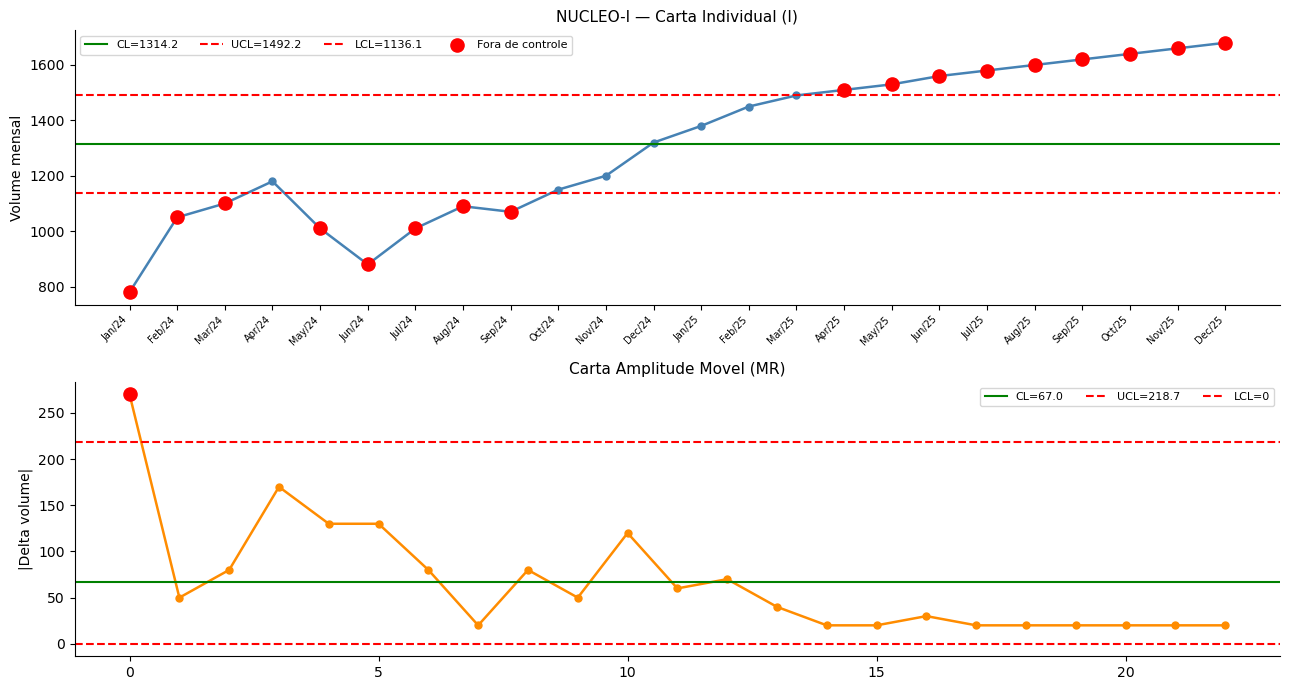

  Pontos fora de controle (carta I): periodos [np.int64(0), np.int64(1), np.int64(2), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]

=== NUCLEO-II — Carta I-MR ===
  Salvo: AED_inventario_graficos/gaeco_imr.png


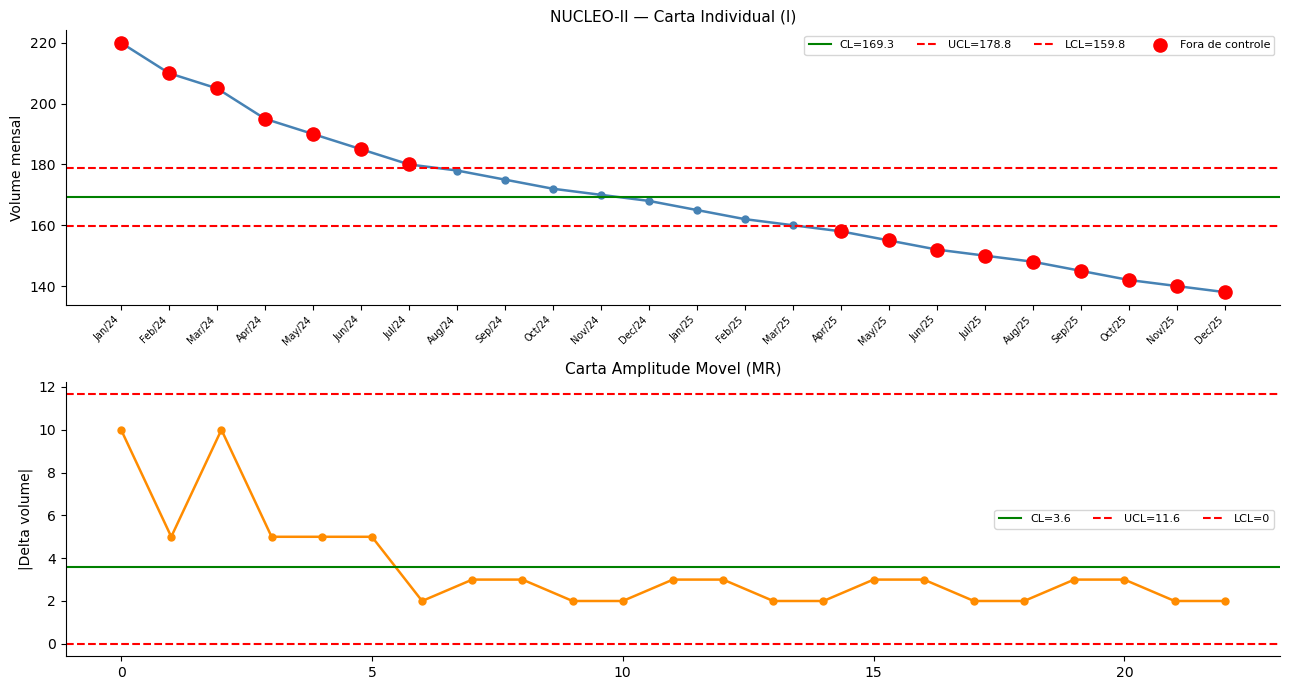

  Pontos fora de controle (carta I): periodos [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]


In [26]:
print('=== NUCLEO-I — Carta I-MR ===')
rot_ij = ts_ij['periodo'].dt.strftime('%b/%y').tolist()
ooc_ij = imr_chart(ts_ij['volume'].values, titulo='NUCLEO-I',
                   rotulos=rot_ij, salvar_como='cao_ij_imr')

print()
print('=== NUCLEO-II — Carta I-MR ===')
rot_g = ts_gaeco['periodo'].dt.strftime('%b/%y').tolist()
ooc_g = imr_chart(ts_gaeco['volume'].values, titulo='NUCLEO-II',
                  rotulos=rot_g, salvar_como='gaeco_imr')

In [27]:
# ─── DESCRIÇÃO TEXTUAL DOS GRÁFICOS: Cartas I-MR ─────────────────────────────
def _desc_imr(ts_df, nome, arquivo, rotulos):
    _x    = ts_df['volume'].values.astype(float)
    _mr   = np.abs(np.diff(_x))
    _xbar = _x.mean()
    _mrbar = _mr.mean()
    _d2   = 1.128
    _sig_est = _mrbar / _d2
    _ucl_x   = _xbar + 3 * _sig_est
    _lcl_x   = max(0.0, _xbar - 3 * _sig_est)
    _ucl_mr  = 3.267 * _mrbar
    _ooc_i   = np.where((_x > _ucl_x) | (_x < _lcl_x))[0]
    _ooc_mr  = np.where(_mr > _ucl_mr)[0]

    print(f"── {nome} ────────────────────────────────────────────────────────")
    print(f"  Arquivo    : {arquivo}")
    print(f"  Tipo       : Carta Individual (I) + Amplitude Móvel (MR) — 2 painéis empilhados")
    print(f"  Figura     : 13×7 pol.")
    print(f"  Método     : Montgomery (2009), 3-sigma; d₂=1,128 (fator MR para n=2)")
    print(f"  n          : {len(_x)} observações mensais")
    print()
    print(f"  CARTA I — LIMITES DE CONTROLE (volume mensal):")
    print(f"    Linha central  CL  = {_xbar:.2f} processos/mês")
    print(f"    Limite superior UCL = {_ucl_x:.2f}  (CL + 3·σ̂)")
    print(f"    Limite inferior LCL = {_lcl_x:.2f}  (CL − 3·σ̂, mín=0)")
    print(f"    σ̂ estimado (MR̄/d₂) = {_sig_est:.2f}")
    print()
    print(f"  CARTA MR — LIMITES DE CONTROLE (amplitude móvel entre meses):")
    print(f"    Linha central  CL  = {_mrbar:.2f}  (média das amplitudes móveis)")
    print(f"    Limite superior UCL = {_ucl_mr:.2f}  (D₄ × MR̄ = 3,267 × {_mrbar:.2f})")
    print(f"    Limite inferior LCL = 0,00  (D₃ não definido para n=2)")
    print()
    print(f"  DADOS — Carta I:")
    print(f"  {'Período':<10} {'Volume':>8} {'Diferença':>11} {'Status':>18}")
    print(f"  {'-'*50}")
    for _i, (_rot, _val) in enumerate(zip(rotulos, _x)):
        _status = "** FORA DE CONTROLE **" if _i in _ooc_i else "em controle"
        _diff   = f"{_x[_i]-_xbar:+.1f}" if True else ""
        print(f"  {_rot:<10} {_val:>8.0f} {_diff:>11} {_status:>18}")
    print()
    print(f"  DADOS — Carta MR:")
    print(f"  {'Transição':<22} {'|Δ|':>8} {'Status':>18}")
    print(f"  {'-'*50}")
    for _i, _mr_val in enumerate(_mr):
        _trans  = f"{rotulos[_i]}→{rotulos[_i+1]}"
        _status = "** FORA DE CONTROLE **" if _i in _ooc_mr else "em controle"
        print(f"  {_trans:<22} {_mr_val:>8.0f} {_status:>18}")
    print()
    if _ooc_i.size:
        print(f"  ALARMES Carta I  : {[rotulos[_i] for _i in _ooc_i]}")
    else:
        print(f"  Carta I  : todos os {len(_x)} pontos dentro dos limites ±3σ.")
    if _ooc_mr.size:
        print(f"  ALARMES Carta MR : transições {[f'{rotulos[_i]}→{rotulos[_i+1]}' for _i in _ooc_mr]}")
    else:
        print(f"  Carta MR : todos os {len(_mr)} pontos dentro de UCL={_ucl_mr:.1f}.")
    print()

print("=" * 72)
print("GRÁFICOS : Cartas de Controle I-MR — NUCLEO-I e NUCLEO-II")
print("Referência: Montgomery (2009), Introduction to Statistical Quality Control, Cap. 6")
print("Parâmetros: k=3σ, d₂=1,128; ARL₀ ≈ 370 (probabilidade de falso alarme ≈ 0,27%/ponto)")
print("=" * 72)
print()
_rot_ij2 = ts_ij['periodo'].dt.strftime('%b/%y').tolist()
_rot_g2  = ts_gaeco['periodo'].dt.strftime('%b/%y').tolist()
_desc_imr(ts_ij,    'NUCLEO-I',          'cao_ij_imr.png',  _rot_ij2)
_desc_imr(ts_gaeco, 'NUCLEO-II', 'gaeco_imr.png',   _rot_g2)
print("=" * 72)

GRÁFICOS : Cartas de Controle I-MR — NUCLEO-I e NUCLEO-II
Referência: Montgomery (2009), Introduction to Statistical Quality Control, Cap. 6
Parâmetros: k=3σ, d₂=1,128; ARL₀ ≈ 370 (probabilidade de falso alarme ≈ 0,27%/ponto)

── NUCLEO-I ────────────────────────────────────────────────────────
  Arquivo    : cao_ij_imr.png
  Tipo       : Carta Individual (I) + Amplitude Móvel (MR) — 2 painéis empilhados
  Figura     : 13×7 pol.
  Método     : Montgomery (2009), 3-sigma; d₂=1,128 (fator MR para n=2)
  n          : 24 observações mensais

  CARTA I — LIMITES DE CONTROLE (volume mensal):
    Linha central  CL  = 1314.17 processos/mês
    Limite superior UCL = 1492.24  (CL + 3·σ̂)
    Limite inferior LCL = 1136.09  (CL − 3·σ̂, mín=0)
    σ̂ estimado (MR̄/d₂) = 59.36

  CARTA MR — LIMITES DE CONTROLE (amplitude móvel entre meses):
    Linha central  CL  = 66.96  (média das amplitudes móveis)
    Limite superior UCL = 218.75  (D₄ × MR̄ = 3,267 × 66.96)
    Limite inferior LCL = 0,00  (D₃ nã

=== NUCLEO-I — CUSUM ===
  Salvo: AED_inventario_graficos/cao_ij_cusum.png


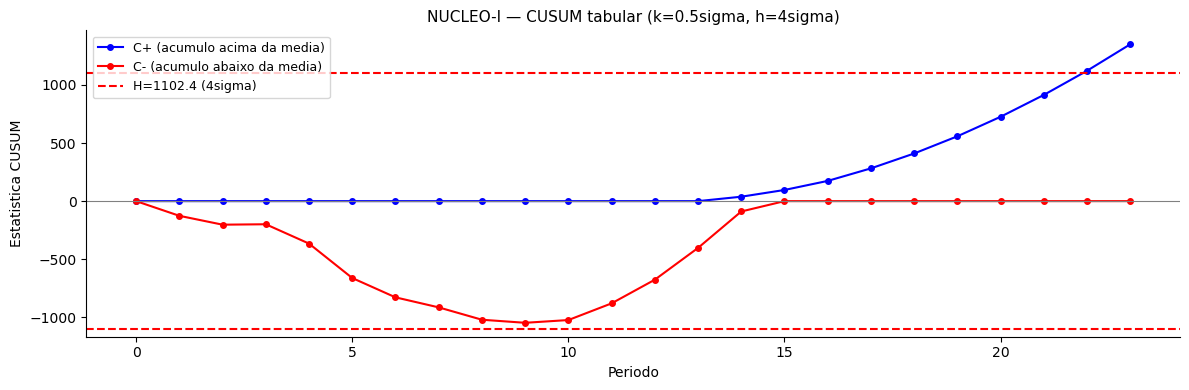

  Sinal CUSUM detectado nos periodos: [np.int64(22), np.int64(23)]

=== NUCLEO-II — CUSUM ===
  Salvo: AED_inventario_graficos/gaeco_cusum.png


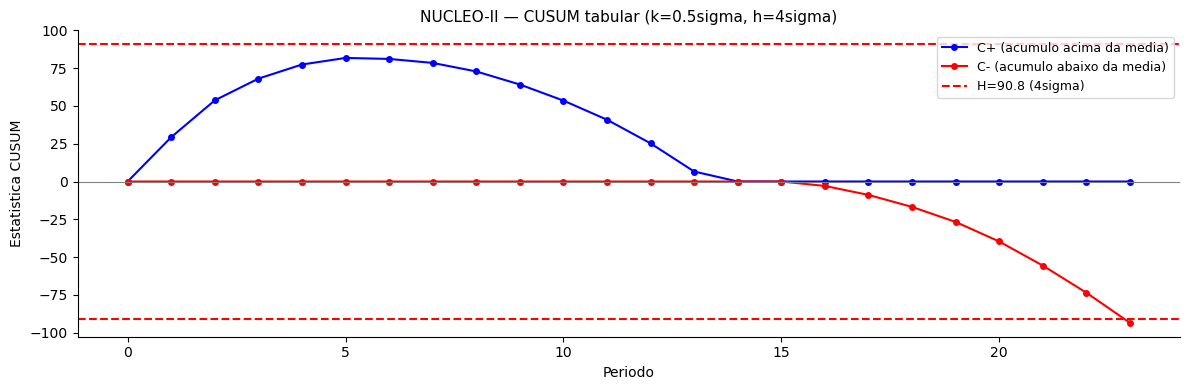

  Sinal CUSUM detectado nos periodos: [np.int64(23)]

Interpretacao:
  k=0.5sigma: detecta desvios >= 1sigma da media
  h=4sigma  : ARL0 aprox 465 meses


In [28]:
print('=== NUCLEO-I — CUSUM ===')
sigs_ij = cusum_chart(ts_ij['volume'].values, titulo='NUCLEO-I',
                      salvar_como='cao_ij_cusum')

print()
print('=== NUCLEO-II — CUSUM ===')
sigs_g  = cusum_chart(ts_gaeco['volume'].values, titulo='NUCLEO-II',
                      salvar_como='gaeco_cusum')

print()
print('Interpretacao:')
print('  k=0.5sigma: detecta desvios >= 1sigma da media')
print('  h=4sigma  : ARL0 aprox 465 meses')

In [29]:
# ─── DESCRIÇÃO TEXTUAL DOS GRÁFICOS: Cartas CUSUM ────────────────────────────
def _desc_cusum(ts_df, nome, arquivo, k=0.5, h=4):
    _x    = ts_df['volume'].values.astype(float)
    _mu   = _x.mean()
    _sig  = _x.std(ddof=1)
    _K    = k * _sig
    _H    = h * _sig
    _n    = len(_x)
    _Cp   = np.zeros(_n)
    _Cn   = np.zeros(_n)
    for _i in range(1, _n):
        _Cp[_i] = max(0, _Cp[_i-1] + (_x[_i] - _mu) - _K)
        _Cn[_i] = max(0, _Cn[_i-1] - (_x[_i] - _mu) - _K)
    _sigs  = np.where((_Cp > _H) | (_Cn > _H))[0]
    _rots  = ts_df['periodo'].dt.strftime('%b/%y').tolist()

    print(f"── {nome} ────────────────────────────────────────────────────────")
    print(f"  Arquivo    : {arquivo}")
    print(f"  Tipo       : CUSUM tabular bilateral (acumulativo)")
    print(f"  Figura     : 12×4 pol.")
    print(f"  Referência : Montgomery (2009); Lucas & Crosier (1982)")
    print(f"  n          : {_n} observações mensais")
    print()
    print(f"  PARÂMETROS DA CARTA:")
    print(f"    Média de referência  μ  = {_mu:.2f} processos/mês")
    print(f"    Desvio-padrão        σ  = {_sig:.2f}")
    print(f"    Folga de referência  k  = {k}σ = {_K:.2f}  (detecta desvios ≥ 1σ da média)")
    print(f"    Barreira de decisão  h  = {h}σ = {_H:.2f}  (ARL₀ ≈ 465 meses)")
    print()
    print(f"  SÉRIES EXIBIDAS NO GRÁFICO:")
    print(f"    C+ (linha azul)   : acumula evidência de aumento acima de μ")
    print(f"    C- (linha vermelha, exibida como −C−): acumula evidência de queda abaixo de μ")
    print(f"    Linhas de decisão : ±H = ±{_H:.2f}  (cruzamento = sinal de mudança)")
    print()
    print(f"  DADOS DAS ESTATÍSTICAS CUSUM:")
    print(f"  {'Período':<10} {'Volume':>8} {'C+':>9} {'C-':>9} {'-C-':>9} {'Sinal':>8}")
    print(f"  {'-'*57}")
    for _i in range(_n):
        _sinal = "* SINAL" if _i in _sigs else "     —"
        print(f"  {_rots[_i]:<10} {_x[_i]:>8.0f} {_Cp[_i]:>9.2f} {_Cn[_i]:>9.2f} {-_Cn[_i]:>9.2f} {_sinal:>8}")
    print()
    if _sigs.size:
        _detalhes = []
        for _i in _sigs:
            _tipo = "C+" if _Cp[_i] > _H else "C-"
            _detalhes.append(f"{_rots[_i]}({_tipo}={_Cp[_i] if _tipo=='C+' else _Cn[_i]:.1f})")
        print(f"  SINAIS DETECTADOS ({len(_sigs)} pontos): {_detalhes}")
    else:
        print(f"  Nenhum sinal detectado — processo estável no período monitorado.")
    print()

print("=" * 72)
print("GRÁFICOS : Cartas CUSUM Tabulares — NUCLEO-I e NUCLEO-II")
print("Referência: Montgomery (2009); Lucas & Crosier (1982), Technometrics")
print("Parâmetros: k=0,5σ (folga de referência), h=4σ (barreira de decisão)")
print("ARL₀ ≈ 465 meses (tempo médio até falso alarme sob processo estável)")
print("Vantagem sobre I-MR: detecta deslocamentos sustentados pequenos (≥1σ) mais rapidamente")
print("=" * 72)
print()
_desc_cusum(ts_ij,    'NUCLEO-I',          'cao_ij_cusum.png')
_desc_cusum(ts_gaeco, 'NUCLEO-II', 'gaeco_cusum.png')
print("=" * 72)

GRÁFICOS : Cartas CUSUM Tabulares — NUCLEO-I e NUCLEO-II
Referência: Montgomery (2009); Lucas & Crosier (1982), Technometrics
Parâmetros: k=0,5σ (folga de referência), h=4σ (barreira de decisão)
ARL₀ ≈ 465 meses (tempo médio até falso alarme sob processo estável)
Vantagem sobre I-MR: detecta deslocamentos sustentados pequenos (≥1σ) mais rapidamente

── NUCLEO-I ────────────────────────────────────────────────────────
  Arquivo    : cao_ij_cusum.png
  Tipo       : CUSUM tabular bilateral (acumulativo)
  Figura     : 12×4 pol.
  Referência : Montgomery (2009); Lucas & Crosier (1982)
  n          : 24 observações mensais

  PARÂMETROS DA CARTA:
    Média de referência  μ  = 1314.17 processos/mês
    Desvio-padrão        σ  = 275.60
    Folga de referência  k  = 0.5σ = 137.80  (detecta desvios ≥ 1σ da média)
    Barreira de decisão  h  = 4σ = 1102.40  (ARL₀ ≈ 465 meses)

  SÉRIES EXIBIDAS NO GRÁFICO:
    C+ (linha azul)   : acumula evidência de aumento acima de μ
    C- (linha vermelha, ex

---
## 7. Síntese e Recomendações

### Características dos dois projetos

| Dimensão | NUCLEO-I | NUCLEO-II |
|---|---|---|
| Volume médio/mês | ~1.300 processos | ~170 processos |
| Taxa de finalização | ~55% | ~20% |
| Tipo processual | 50% judicial / 50% extrajudicial | 93% extrajudicial |
| Natureza jurídica | Cível + Infracional | Investigativo |
| Variabilidade esperada | Menor | Maior |

### Recomendações

1. **Estacionário + sem autocorrelação** → Cartas I-MR e CUSUM aplicáveis diretamente
2. **Com autocorrelação** (Ljung-Box p<0,05) → Carta EWMA ou resíduos ARIMA
3. **Com tendência** (Mann-Kendall p<0,05) → Modelar tendência explicitamente; monitorar resíduos
4. **Ampliar série temporal**: incluir anos anteriores aumenta poder dos testes (n≥36 para STL period=12)
5. **Estratificar** por `TIPO_CLASSE` — judiciais e extrajudiciais têm dinâmicas distintas

---
## Referências Acadêmicas

### Séries Temporais
- **Box, G.E.P., Jenkins, G.M., Reinsel, G.C., & Ljung, G.M.** (2015). *Time Series Analysis: Forecasting and Control* (5ª ed.). Wiley.
- **Cleveland, R.B., Cleveland, W.S., McRae, J.E., & Terpenning, I.** (1990). STL: A seasonal-trend decomposition procedure based on loess. *Journal of Official Statistics*, 6(1), 3–73.
- **Dickey, D.A., & Fuller, W.A.** (1979). Distribution of the estimators for autoregressive time series with a unit root. *JASA*, 74(366), 427–431.
- **Kwiatkowski, D., Phillips, P.C.B., Schmidt, P., & Shin, Y.** (1992). Testing the null hypothesis of stationarity against the alternative of a unit root. *Journal of Econometrics*, 54, 159–178.
- **Ljung, G.M., & Box, G.E.P.** (1978). On a measure of lack of fit in time series models. *Biometrika*, 65(2), 297–303.
- **Mann, H.B.** (1945). Nonparametric tests against trend. *Econometrica*, 13(3), 245–259.
- **Kendall, M.G.** (1975). *Rank Correlation Methods* (4ª ed.). Griffin.
- **Schwert, G.W.** (1989). Tests for unit roots: A Monte Carlo investigation. *JBES*, 7(2), 147–159.

### Controle Estatístico de Processos (CEP)
- **Montgomery, D.C.** (2009). *Introduction to Statistical Quality Control* (6ª ed.). Wiley.
- **Lucas, J.M., & Crosier, R.B.** (1982). Fast initial response for CUSUM quality-control schemes. *Technometrics*, 24(3), 199–205.
- **Wheeler, D.J., & Chambers, D.S.** (1992). *Understanding Statistical Process Control* (2ª ed.). SPC Press.

### Inferência Estatística
- **Efron, B., & Tibshirani, R.J.** (1993). *An Introduction to the Bootstrap*. Chapman & Hall.
- **Mann, H.B., & Whitney, D.R.** (1947). On a test of whether one of two random variables is stochastically larger than the other. *Annals of Mathematical Statistics*, 18(1), 50–60.

## 8. Mapa de Consultas

| Consulta                                     | Filtro / Escopo                               | Métricas calculadas                                                                                                  | Agrupamento                                    | Finalidade na análise                                                                                                              |
| -------------------------------------------- | --------------------------------------------- | -------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------- |
| Série Temporal Mensal (make_ts_sql)          | NUCLEO-I ou NUCLEO-II+NUCLEO-II \| 2024–2025        | COUNT(*) → volume mensal; SUM(fin) → processos finalizados; AVG(dias) → média de permanência; MEDIAN(dias) → mediana | GROUP BY ano, mes_num, mes → ORDER BY ano, mes | Constrói as séries temporais que alimentam todos os testes estatísticos: ADF, KPSS, STL, cartas IMR e CUSUM                        |
| Dados Detalhados por Registro (make_det_sql) | NUCLEO-I ou NUCLEO-II+NUCLEO-II \| 2024–2025        | DIAS_DECORRIDOS, TIPO_CLASSE, ATUACAO, flag binária finalizado                                                       | Nenhum — retorna nível de registro individual  | Insumo para percentis de dias, separação judicial/extrajudicial e gráficos de distribuição                                         |
| Top Áreas de Atuação (make_atu_sql)          | NUCLEO-I ou NUCLEO-II+NUCLEO-II \| 2024–2025, top 10 | COUNT(*) por categoria temática (ATUACAO)                                                                            | GROUP BY ATUACAO → ORDER BY n DESC LIMIT 10    | Identifica as 10 áreas mais frequentes para subsidiar estratificação e reduzir ruído nas séries                                    |
| Sumário NUCLEO-I (Python pós-carga)            | Subconjunto det_ij já em memória              | Total de registros, % finalizados, % pendentes, % judiciais/extrajudiciais, mediana/média/P75/P90 de dias            | Calculado em pandas sobre det_ij               | Snapshot descritivo geral do NUCLEO-I: 33.749 registros, mix 50/50 judicial, assimetria de DIAS_DECORRIDOS                           |
| Distribuição por Unidade NUCLEO-II               | NUCLEO-II + NUCLEO-II \| 2024–2025                | COUNT(*) e SUM(fin) por NOME_ORGAO                                                                                   | GROUP BY NOME_ORGAO → ORDER BY n DESC          | Confirma que todos os registros NUCLEO-II pertencem ao NUCLEO-II, eliminando necessidade de filtro adicional                           |
| Sumário NUCLEO-II (Python pós-carga)   | Subconjunto det_gaeco já em memória           | Total de registros, % finalizados, % pendentes, % judiciais/extrajudiciais, mediana/média/P75/P90 de dias            | Calculado em pandas sobre det_gaeco            | Snapshot descritivo do NUCLEO-II: 4.431 registros, 93% extrajudicial, mediana de 559–900 dias (perfil radicalmente distinto do NUCLEO-I) |